In [1]:
#Installs on colab
def running_on_colab():
    try:
        import google.colab  # type: ignore
        return True
    except ImportError:
        return False

if running_on_colab():
    print("Running on Colab. Installing dependencies...")
    !pip install -q atomai neuraloperator ipympl ipywidgets hoffmanstmpy

    from google.colab import output
    output.enable_custom_widget_manager()

    !git clone -b ayush_dev --single-branch https://github.com/gnganesh99/NN_Error.git
    %cd NN_Error

    print("Colab setup complete.")

Running on Colab. Installing dependencies...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 kB 18.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.0/179.0 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.6/248.6 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.3/145.3 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 160.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 146.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import sys
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset
import os
from scipy.ndimage import zoom
import pandas as pd


# try:
#     get_ipython().run_line_magic("matplotlib", "widget")
# except (ValueError, RuntimeError):
#     get_ipython().run_line_magic("matplotlib", "inline")
# import matplotlib.pyplot as plt


# Make package and notebook-local helper modules importable whether this starts in repo root or notebooks/
repo_root = Path.cwd() if (Path.cwd() / "src" / "nnerror").exists() else Path.cwd().parent.parent
src_root = str((repo_root / "src").resolve())
nb_root = str((repo_root / "notebooks"/"STM").resolve())
for import_root in (src_root, nb_root):
    if import_root not in sys.path:
        sys.path.insert(0, import_root)




from nnerror.networks import FNO_im2spec, CustomDecoder, im2spec, im2spec_attn, FNO_im2spec_attn
from nnerror.training_functions import err_estimation, train_model, predict_spectra, norm_0to1, predict_posterior, append_training_set
from nnerror.plot_functions import plot_only_training_loss, plot_training_loss, \
    plot_error_prediction, plot_spectra, plot_scale_slider, plot_latent_space, cluster_latent_space, plot_latent_distribution, plot_scale_specific_error_and_acquisition_maps
from nnerror.utils import append_multiscale_data, edges_zeroed_image, interpolated_center_crop, paired_images_spectra_1
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [3]:
# For training reproducibility
import random
seed = 42
 
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
	
class Norm_G:
    """Gaussian normalization using mean and standard deviation."""

    def __init__(self, data=None, mean=None, std=None, axis=0, eps=1e-8):
        self.data = data
        self.axis = axis
        self.eps = eps

        if data is not None:
            self.mean = np.mean(data, axis=axis, keepdims=True)
            self.std = np.std(data, axis=axis, keepdims=True)
        elif mean is not None and std is not None:
            self.mean = mean
            self.std = std
        else:
            raise ValueError("Either data or both mean and std must be provided.")

        self.std = np.where(self.std < eps, eps, self.std)

    def normalize(self, data=None):
        """Normalize data using stored mean and std."""
        if data is None:
            data = self.data
        return (data - self.mean) / self.std

    def denormalize(self, normalized_data):
        """Denormalize data using stored mean and std."""
        return normalized_data * self.std + self.mean


class Norm_0to1:
    """Normalization to the range [0, 1]."""

    def __init__(self, data=None, min_val=None, max_val=None, axis=0, eps=1e-8):
        self.data = data
        self.axis = axis
        self.eps = eps

        if data is not None:
            self.min_val = np.min(data, axis=axis, keepdims=True)
            self.max_val = np.max(data, axis=axis, keepdims=True)
        elif min_val is not None and max_val is not None:
            self.min_val = min_val
            self.max_val = max_val
        else:
            raise ValueError("Either data or both min_val and max_val must be provided.")

        self.data_range = np.where(
            (self.max_val - self.min_val) < eps,
            eps,
            self.max_val - self.min_val
        )

    def normalize(self, data=None):
        """Normalize data using stored min and max."""
        if data is None:
            if self.data is None:
                raise ValueError("No data provided to normalize.")
            data = self.data

        return (data - self.min_val) / self.data_range

    def denormalize(self, normalized_data):
        """Denormalize data using stored min and max."""
        return normalized_data * self.data_range + self.min_val

In [54]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

def extract_beps_data():
    """
    Extracts BEPS data from h5 file.
    """

    !wget -q "https://www.dropbox.com/scl/fi/sitkzwu8uk04ygru8edf1/BEPS_1d5um_0001.h5?rlkey=oz7b9zue2ftxiix6e5mal0szh&dl=1" -O BEPS.h5
    wget -q "https://www.dropbox.com/scl/fi/syjh9jp0mn9pturbjgs82/FORC_BEPS_1d8um_0010.h5?rlkey=27kndbclb9pxapjic1t62uyak&dl=0" -O BEPS.h5
    h5_f = h5py.File("BEPS.h5", "r")

    #sho_mat = h5_f["Measurement_000/Channel_000/Raw_Data-SHO_Fit_001/Fit"]
    sho_mat = h5_f["Measurement_000/Channel_000/Raw_Data-SHO_Fit_000/Guess"]
    spec_val = h5_f["Measurement_000/Channel_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values"]
    pos_inds = h5_f["Measurement_000/Channel_000/Position_Indices"]

    pos_dim_sizes = [
        np.max(pos_inds[:, 0]) + 1,
        np.max(pos_inds[:, 1]) + 1,
    ]

    #topo = h5_f["Measurement_000/Channel_001/Raw_Data"]["r"]
    topo = None


    sho_mat_ndim = sho_mat[:].reshape(
        pos_dim_sizes[0],
        pos_dim_sizes[1],
        -1,
    )

    amp_mat_ndim = sho_mat_ndim["Amplitude [V]"]
    phase_mat_ndim = sho_mat_ndim["Phase [rad]"]
    fre_mat_ndim = sho_mat_ndim["Frequency [Hz]"]
    q_mat_ndim = sho_mat_ndim["Quality Factor"]

    topo = np.mean(amp_mat_ndim, axis=2)

    return (
        sho_mat_ndim,
        amp_mat_ndim,
        phase_mat_ndim,
        fre_mat_ndim,
        q_mat_ndim,
        spec_val,
        pos_inds,
        pos_dim_sizes,
        topo,
    )


def process_beps_data(
    amp_mat_ndim,
    pha_correct,
    fre_mat_ndim,
    spec_val,
):
    """
    Split BEPS data into on- and off-field responses and compute polarization.
    """

    full_spec_len = amp_mat_ndim.shape[2]
    spec_len = full_spec_len // 2
    pix_x, pix_y = amp_mat_ndim.shape[:2]

    amp_off = np.zeros((pix_x, pix_y, spec_len))
    pha_off = np.zeros((pix_x, pix_y, spec_len))
    fre_off = np.zeros((pix_x, pix_y, spec_len))

    amp_on = np.zeros((pix_x, pix_y, spec_len))
    pha_on = np.zeros((pix_x, pix_y, spec_len))
    fre_on = np.zeros((pix_x, pix_y, spec_len))

    v_step = np.zeros(spec_len)

    for i in range(spec_len):
        amp_off[:, :, i] = amp_mat_ndim[:, :, 2*i + 1]
        pha_off[:, :, i] = pha_correct[:, :, 2*i + 1]
        fre_off[:, :, i] = fre_mat_ndim[:, :, 2*i + 1] / 1000

        amp_on[:, :, i] = amp_mat_ndim[:, :, 2*i]
        pha_on[:, :, i] = pha_correct[:, :, 2*i]
        fre_on[:, :, i] = fre_mat_ndim[:, :, 2*i] / 1000

        v_step[i] = spec_val[0, 2*i]

    pola_off = amp_off * np.cos(pha_off)

    return (
        amp_off,
        pha_off,
        fre_off,
        amp_on,
        pha_on,
        fre_on,
        pola_off,
        v_step,
    )


def plot_average_beps_curves(
    amp_off,
    pha_off,
    fre_off,
    pola_off,
    v_step,
):
    fig, axes = plt.subplots(1, 4, figsize=(24, 4))

    axes[0].plot(v_step, amp_off.mean(axis=(0, 1)))
    axes[0].set_xlabel("Voltage (V)")
    axes[0].set_ylabel("Amplitude")

    axes[1].plot(v_step, pha_off.mean(axis=(0, 1)))
    axes[1].set_xlabel("Voltage (V)")
    axes[1].set_ylabel("Phase (rad)")

    axes[2].plot(v_step, fre_off.mean(axis=(0, 1)))
    axes[2].set_xlabel("Voltage (V)")
    axes[2].set_ylabel("Frequency (kHz)")

    axes[3].plot(v_step, pola_off.mean(axis=(0, 1)))
    axes[3].set_xlabel("Voltage (V)")
    axes[3].set_ylabel("Polarization")

    plt.tight_layout()


def plot_beps_pixels(
    pola_off,
    amp_off,
    v_step,
    pixel1=(30, 60),
    pixel2=(30, 30),
):
    structure = amp_off.mean(axis=2)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))

    ax1.plot(v_step, pola_off[pixel1], "k")
    ax1.plot(v_step, pola_off[pixel2], "r")
    ax1.set_xlabel("Voltage (V)")
    ax1.set_ylabel("Polarization")

    ax2.imshow(structure)
    ax2.scatter(pixel1[1], pixel1[0], marker="x", s=100, c="k")
    ax2.scatter(pixel2[1], pixel2[0], marker="x", s=100, c="r")
    ax2.set_title("Structure Image")
    ax2.axis("off")

    plt.tight_layout()


def paired_beps_spectra(
    image,
    spectra_data,
    window_size=32,
    coordinate_step=15,
    image_norm=False,
    spectra_norm=False,
    each_spectrum_norm=False,
):
    """
    Create image patches paired with BEPS spectra.

    image:
        2D structural image (x,y)

    spectra_data:
        3D spectral cube (x,y,spectrum_length)

    Returns:
        images: (N, window_size, window_size)
        spectra: (N, spectrum_length)
        coordinates: (N,2)
    """

    half = window_size // 2

    images = []
    spectra = []
    coordinates = []

    nx, ny = image.shape

    for x in range(half, nx-half, coordinate_step):
        for y in range(half, ny-half, coordinate_step):

            # extract image patch
            patch = image[
                x-half:x+half,
                y-half:y+half
            ]

            # extract spectrum at center pixel
            spectrum = spectra_data[x, y, :]
            if each_spectrum_norm:
                spectrum = (spectrum - spectrum.min()) / (spectrum.max() - spectrum.min() + 1e-48)

            if image_norm:
                patch = (patch - patch.mean()) / (patch.std() + 1e-8)

            images.append(patch)
            spectra.append(spectrum)
            coordinates.append([x, y])

    # Convert to numpy arrays
    images = np.array(images)
    spectra = np.array(spectra)
    coordinates = np.array(coordinates)

    # Global min-max normalization of ALL spectra
    # if spectra_norm:
    #     spec_min = spectra.min()
    #     spec_max = spectra.max()
    #     spectra = (spectra - spec_min) / (spec_max - spec_min + 1e-48)

    return images, spectra, coordinates



In [55]:

def augment_images_by_indices(indices, images, spectra, coordinates, WS_init, WS, d_WS, append_image_type = None, scale_type = "multi_scale"):


    images = images[indices]
    spectra = spectra[indices]
    coordinates = coordinates[indices]


    if scale_type == "single_scale":
        image_scale = images.shape[-1]  # Assuming the last dimension corresponds to the scale
        coordinates = np.hstack([coordinates, image_scale * np.ones((coordinates.shape[0], 1))])
        return images, spectra, coordinates

    if append_image_type is None:
        raise ValueError("append_image_type must be 'pad' or 'interpolate'.")

    images_aug, spectra_aug, coords_aug = append_multiscale_data(images, spectra, scales=np.arange(WS_init, WS, d_WS),
                                                            coordinates=coordinates,
                                                            append_image_type=append_image_type)


    return images_aug, spectra_aug, coords_aug


def reduce_errors_and_coords(predicted_errors, scale_coordinates):

    df_errors = pd.DataFrame({
        "x": scale_coordinates[:, 0],
        "y": scale_coordinates[:, 1],
        "scale": scale_coordinates[:, 2],
        "error": predicted_errors,
    })

    reduced = (
        df_errors.loc[df_errors.groupby(["x", "y"])["error"].idxmin()]
        .sort_values(["x", "y"])
        .reset_index(drop=True)
    )

    errors = reduced["error"].to_numpy()
    coords_reduced = reduced[["x", "y", "scale"]].to_numpy()

    return errors, coords_reduced



def plot_reduced_errors_and_scales(errors, coords_reduced, aq_indices=None, nm_per_pixel=0.4833):
    xs = coords_reduced[:, 0] * nm_per_pixel
    ys = coords_reduced[:, 1] * nm_per_pixel
    scales = coords_reduced[:, 2] * nm_per_pixel

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    sc0 = axes[0].scatter(xs, ys, c=errors, s=80)
    axes[0].set_title("Reduced Minimum Errors, mean = {:.3f}".format(np.mean(errors)))
    axes[0].set_xlabel("x (nm)")
    axes[0].set_ylabel("y (nm)")
    axes[0].set_aspect("equal")
    plt.colorbar(sc0, ax=axes[0], label="Minimum Error")

    sc1 = axes[1].scatter(xs, ys, c=scales, s=80)
    axes[1].set_title("Best Scale at Each (x, y)")
    axes[1].set_xlabel("x (nm)")
    axes[1].set_ylabel("y (nm)")
    axes[1].set_aspect("equal")
    plt.colorbar(sc1, ax=axes[1], label="Best Scale (nm)")

    if aq_indices is not None and len(aq_indices) > 0:
        aq_indices = np.asarray(aq_indices, dtype=int)

        axes[0].scatter(
            xs[aq_indices],
            ys[aq_indices],
            marker="x",
            s=120,
            linewidths=2,
            label="Acquisition points"
        )
        axes[0].legend()

    plt.tight_layout()
    plt.show()



def plot_spectra_grid(spectra, predicted_spectra, error_values, error_type, plots_per_row=5):
    """Plot original and predicted spectra in rows of up to five plots."""
    n_plots = len(spectra)
    if not (n_plots == len(predicted_spectra) == len(error_values)):
        raise ValueError("spectra, predicted_spectra, and error_values must have the same length.")
    if n_plots == 0:
        return

    error_label = {
        "L1": "L1 error",
        "L2": "L2 error",
        "cos": "Cosine error",
    }.get(error_type, f"{error_type} error")
    n_rows = int(np.ceil(n_plots / plots_per_row))
    fig, axes = plt.subplots(
        n_rows, plots_per_row,
        figsize=(4 * plots_per_row, 4 * n_rows),
        squeeze=False
    )

    for ax, spectrum, predicted_spectrum, error_value in zip(
        axes.flat, spectra, predicted_spectra, error_values
    ):
        spectrum = np.asarray(spectrum).squeeze()
        predicted_spectrum = np.asarray(predicted_spectrum).squeeze()
        x = np.arange(len(spectrum))
        ax.plot(x, spectrum, 'o-', color='black', alpha=0.6, label='original_spectrum')
        ax.plot(
            x, predicted_spectrum, linewidth=3,
            label=f'Predicted\n{error_label}: {float(error_value):.4f}'
        )
        ax.legend(fontsize=10)
        ax.set_xlabel('Index')
        ax.set_ylabel('Current (nA)')

    for ax in axes.flat[n_plots:]:
        ax.set_visible(False)

    fig.tight_layout()
    plt.show()



def find_row_indices(original, subset):
    # Map each row (as a tuple) to its index in the original array
    row_to_index = {tuple(row): i for i, row in enumerate(original)}

    # Look up each row in the subset
    indices = np.array([row_to_index[tuple(row)] for row in subset])

    return indices

import h5py
import numpy as np

def save_h5(filename, data_dict):
    """Save a dictionary of arrays to an HDF5 file."""
    with h5py.File(filename, "w") as f:
        for key, value in data_dict.items():
            f.create_dataset(key, data=value)


def load_h5(filename):
    """Load a dictionary of arrays from an HDF5 file."""
    data_dict = {}
    with h5py.File(filename, "r") as f:
        for key in f.keys():
            data_dict[key] = f[key][()]
    return data_dict



def save_h5_ragged(filename, data_dict):
    with h5py.File(filename, "w") as f:
        for key, value_list in data_dict.items():
            group = f.create_group(key)

            for i, value in enumerate(value_list):
                group.create_dataset(str(i), data=np.asarray(value))


def load_h5_ragged(filename):
    data_dict = {}

    with h5py.File(filename, "r") as f:
        for key in f.keys():
            group = f[key]

            values = []
            for name in sorted(group.keys(), key=lambda x: int(x)):
                values.append(group[name][()])

            data_dict[key] = values

    return data_dict


def default_append_image_type(model_type):
    if model_type in ("im2spec", "im2spec_attn"):
        return "pad"
    return "interpolate"

In [56]:
def get_model(model_type, in_dim, out_dim, latent_dim = 3, device = None):
    # ----------------------------
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if model_type == "im2spec":
        model = im2spec(feature_size=in_dim, target_size=out_dim, latent_dim=latent_dim).to(device)

    elif model_type == "FNO":
        model = FNO_im2spec(
            target_size=out_dim,
            latent_dim=latent_dim,
            hidden_channels=32,
            n_modes=(16, 16),
            n_layers=4,
        ).to(device)

    elif model_type == "im2spec_attn":
        model = im2spec_attn(feature_size=in_dim, target_size=out_dim, latent_dim=latent_dim).to(device)
    elif model_type == "FNO_attn":
        model = FNO_im2spec_attn(
            target_size=out_dim,
            latent_dim=latent_dim,
            hidden_channels=32,
            n_modes=(16, 16),
            n_layers=4,
        ).to(device)

    else:
        raise ValueError(f"Unknown model type: {model_type}")

    return model

In [57]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


def plot_error_prediction_3d(
    error_mean,
    aq_fn,
    coordinates,
    ind,
    expt_name="test_expt",
    iter_nb=0,
    save_folder=r"data",
    to_save=False,
    alpha_scale=True,
    colormap="viridis",
):
    """
    Plot 3D scatter maps of predicted error and acquisition values.

    Args:
        error_mean: Flat array of error values.
        aq_fn: Flat array of acquisition values.
        coordinates: Either `(nx, ny, nz, 3)` gridded coordinates or `(N, 3)`
            flat coordinates. `error_mean` and `aq_fn` must match the flattened
            coordinate order.
        ind: Candidate index or indices selected for acquisition. Currently
            retained for API consistency.
        expt_name: Subfolder name used when saving.
        iter_nb: Iteration number included in the saved filename.
        save_folder: Root folder for saved figures.
        to_save: If True, save the figure before showing it.
        alpha_scale: If True, scale point alpha by normalized values.
        colormap: Matplotlib colormap name.

    Raises:
        ValueError: If coordinate dimensions or flattened lengths are invalid.
    """

    coordinates = np.asarray(coordinates)

    # ---------------------------------------------------------------
    # 1. Get per-axis sizes from `coordinates` -- no cubic assumption.
    # ---------------------------------------------------------------
    if coordinates.ndim == 4:
        nx, ny, nz, _ = coordinates.shape
        coords_flat = coordinates.reshape(-1, 3)
    elif coordinates.ndim == 2:
        nx = len(np.unique(coordinates[:, 0]))
        ny = len(np.unique(coordinates[:, 1]))
        nz = len(np.unique(coordinates[:, 2]))
        coords_flat = coordinates
    else:
        raise ValueError(
            f"coordinates must be 2D (N, 3) or 4D (nx, ny, nz, 3), "
            f"got shape {coordinates.shape}"
        )

    n_total = nx * ny * nz
    if len(error_mean) != n_total or len(aq_fn) != n_total:
        raise ValueError(
            f"Length mismatch: coordinates imply {n_total} points "
            f"(nx={nx}, ny={ny}, nz={nz}), but got "
            f"error_mean of length {len(error_mean)} and "
            f"aq_fn of length {len(aq_fn)}."
        )

    err_flat = np.asarray(error_mean).ravel()
    aq_flat  = np.asarray(aq_fn).ravel()

    nm_per_pixel = 1500/75
    xs = coords_flat[:, 0] * nm_per_pixel
    ys = coords_flat[:, 1] * nm_per_pixel
    zs = coords_flat[:, 2] * nm_per_pixel

    # ---------------------------------------------------------------
    # 2. Helper: build per-point RGBA so alpha is baked into the color.
    #    3D scatter chokes when you pass `alpha=` as an array, so we
    #    sidestep that path entirely.
    # ---------------------------------------------------------------
    def values_to_rgba(values, cmap_name="viridis", vmin=None, vmax=None,
                       min_alpha=0.05, max_alpha=0.9, use_alpha=True):
        """Convert scalar values to RGBA colors and a normalization object."""
        v = values.astype(float)
        lo = v.min() if vmin is None else vmin
        hi = v.max() if vmax is None else vmax
        rng = hi - lo
        norm = (v - lo) / rng if rng > 0 else np.zeros_like(v)
        rgba = plt.get_cmap(cmap_name)(norm)
        if use_alpha:
            rgba[:, -1] = min_alpha + norm * (max_alpha - min_alpha)
        return rgba, Normalize(vmin=lo, vmax=hi)

    err_rgba, err_norm = values_to_rgba(err_flat, cmap_name=colormap, use_alpha=alpha_scale)
    aq_rgba,  aq_norm  = values_to_rgba(aq_flat, cmap_name=colormap, vmin=0, use_alpha=alpha_scale)

    # ---------------------------------------------------------------
    # 3. Two 3D scatter subplots.
    # ---------------------------------------------------------------
    fig = plt.figure(figsize=(12, 5))
    ax0 = fig.add_subplot(1, 2, 1, projection="3d")
    ax1 = fig.add_subplot(1, 2, 2, projection="3d")

    # --- Error map ---
    ax0.scatter(xs, ys, zs, c=err_rgba, s=20, edgecolors="none")

    # highlight the next selected point
    # ax0.scatter(
    #     xs[ind], ys[ind], zs[ind],
    #     c="red", s=80, edgecolors="black", linewidths=1.0,
    #     depthshade=False,
    # )
    ax0.set_title("Error Map")
    ax0.set_xlabel("x(nm)"); ax0.set_ylabel("y(nm)"); ax0.set_zlabel("Scale (nm)")
    fig.colorbar(ScalarMappable(norm=err_norm, cmap=colormap),
                 ax=ax0, fraction=0.04, pad=0.08)

    # --- Acquisition function ---
    ax1.scatter(xs, ys, zs, c=aq_rgba, s=20, edgecolors="none")
    ax1.set_title("Acquisition Function")
    ax1.set_xlabel("x(nm)"); ax1.set_ylabel("y(nm)"); ax1.set_zlabel("z(nm)")
    fig.colorbar(ScalarMappable(norm=aq_norm, cmap=colormap),
                 ax=ax1, fraction=0.04, pad=0.08)

    plt.tight_layout()

    # ---------------------------------------------------------------
    # 4. Optional save.
    # ---------------------------------------------------------------
    if to_save:
        img_name = "errormap_iter" + str(iter_nb) + ".jpg"
        out_dir = os.path.join(save_folder, expt_name)
        os.makedirs(out_dir, exist_ok=True)
        img_path = os.path.join(out_dir, img_name)
        plt.savefig(img_path, bbox_inches="tight")

    plt.show()

# Get data

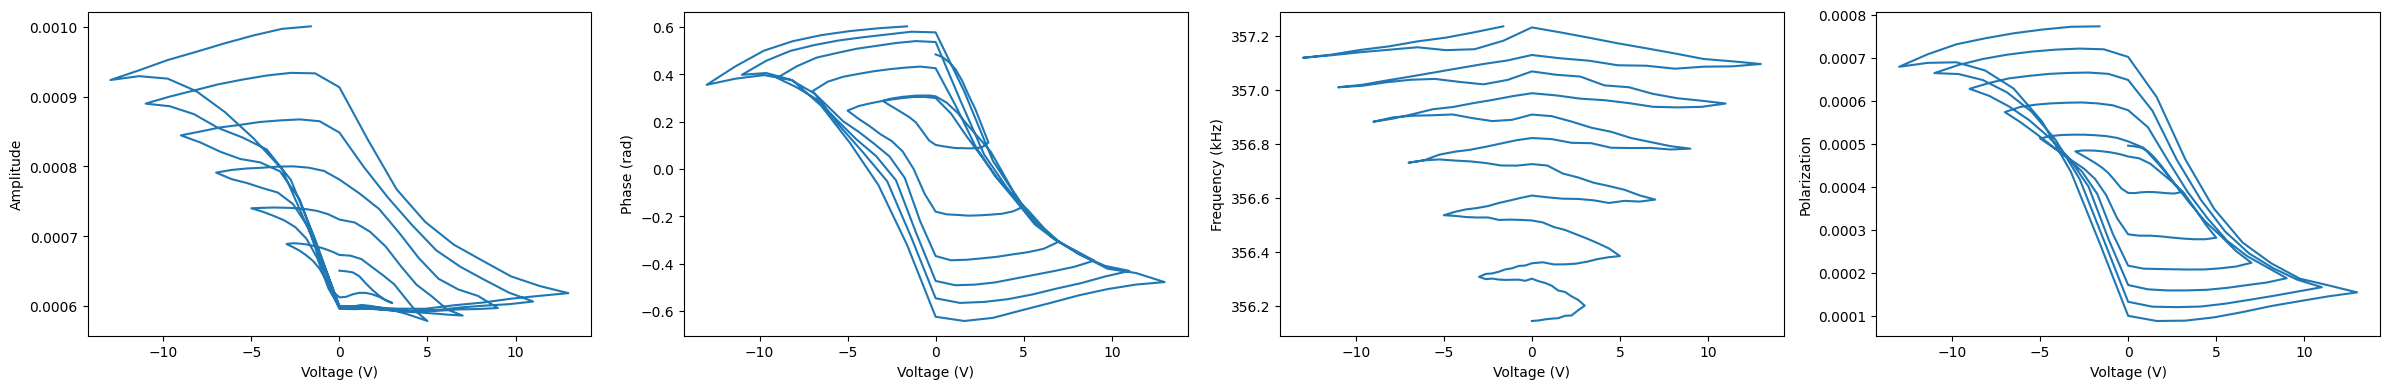

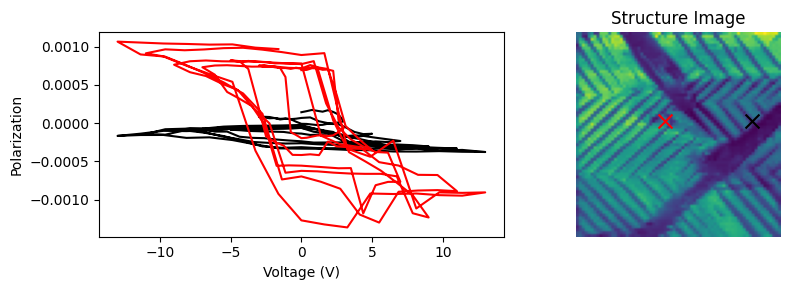

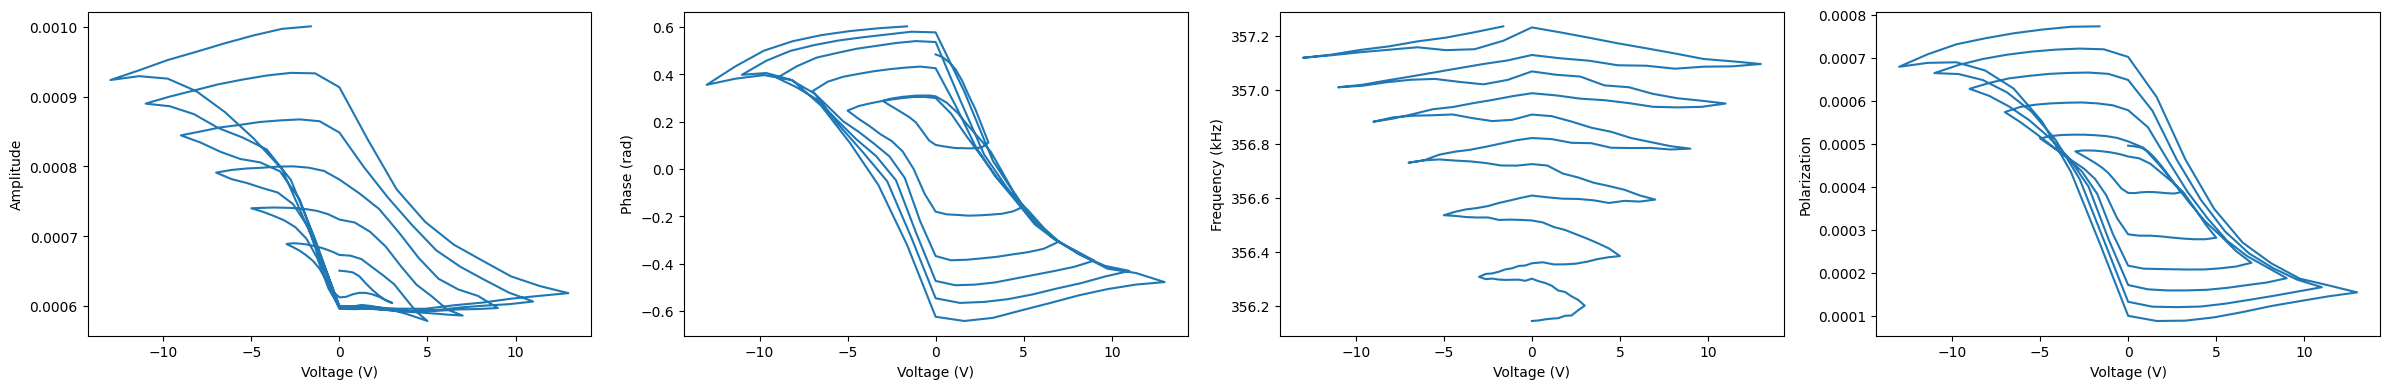

In [58]:
(
    sho_mat_ndim,
    amp_mat_ndim,
    phase_mat_ndim,
    fre_mat_ndim,
    q_mat_ndim,
    spec_val,
    pos_inds,
    pos_dim_sizes,
    topo,
) = extract_beps_data()
(
    amp_off,
    pha_off,
    fre_off,
    amp_on,
    pha_on,
    fre_on,
    pola_off,
    v_step,
) = process_beps_data(
    amp_mat_ndim,
    phase_mat_ndim,
    fre_mat_ndim,
    spec_val,
)
plot_average_beps_curves(
    amp_off,
    pha_off,
    fre_off,
    pola_off,
    v_step,
)

plot_beps_pixels(
    pola_off,
    amp_off,
    v_step,
    pixel1=(30, 60),
    pixel2=(30, 30),
)

plot_average_beps_curves(
    amp_off,
    pha_off,
    fre_off,
    pola_off,
    v_step,
)


In [59]:
min_ = np.min(phase_mat_ndim)
max_ = np.max(phase_mat_ndim)
pha_correct = np.where(phase_mat_ndim > 1.5, phase_mat_ndim + (min_-max_), phase_mat_ndim)

full_spec_len = sho_mat_ndim.shape[2]
spec_len = int(full_spec_len/2)
pix_x, pix_y = sho_mat_ndim.shape[0], sho_mat_ndim.shape[1]

amp_off_field = np.zeros((pix_x, pix_y, spec_len))
pha_off_field = np.zeros((pix_x, pix_y, spec_len))
fre_off_field = np.zeros((pix_x, pix_y, spec_len))

amp_on_field = np.zeros((pix_x, pix_y, spec_len))
pha_on_field = np.zeros((pix_x, pix_y, spec_len))
fre_on_field = np.zeros((pix_x, pix_y, spec_len))

v_step = np.zeros(spec_len)

for i in range (spec_len):
  amp_off_field[:,:, i] = amp_mat_ndim[:,:,2*i+1]
  pha_off_field[:,:, i] = pha_correct[:,:,2*i+1]
  fre_off_field[:,:, i] = fre_mat_ndim[:,:,2*i+1]/1000
  amp_on_field[:,:, i] = amp_mat_ndim[:,:,2*i]
  pha_on_field[:,:, i] = pha_correct[:,:,2*i]
  fre_on_field[:,:, i] = fre_mat_ndim[:,:,2*i]/1000
  v_step[i] = spec_val[0,2*i]

pola_off_field = amp_off_field*np.cos(pha_off_field)

In [60]:
print(amp_off_field.shape[2])

192


In [61]:
WS = 24
WS_init = 4
d_WS = 4

n_epochs_im2spec = 200
n_epochs_error = 200

error_type = "L1"   # "L1", "L2", or "cos"

model_type = "im2spec"

append_image_type = (
    "pad"
    if model_type in ["im2spec", "im2spec_attn", "CustomCNN"]
    else "interpolate"
)

use_swa = True
latent_dim = 5
last_swa_epochs = 100
each_spectrum_norm = False

scale = "singlescale"

nm_per_pixel = 1500/75

In [12]:
struc_img = amp_off_field.mean(axis=2)

In [111]:
images, spectra, coordinates = paired_beps_spectra(
    struc_img,
    pola_off_field,
    window_size=WS,
    coordinate_step=1,
    image_norm=False,
    spectra_norm=False,
    each_spectrum_norm=True,
)

print("images:", images.shape)
print("spectra:", spectra.shape)
print("coordinates:", coordinates.shape)

images: (2116, 24, 24)
spectra: (2116, 192)
coordinates: (2116, 2)


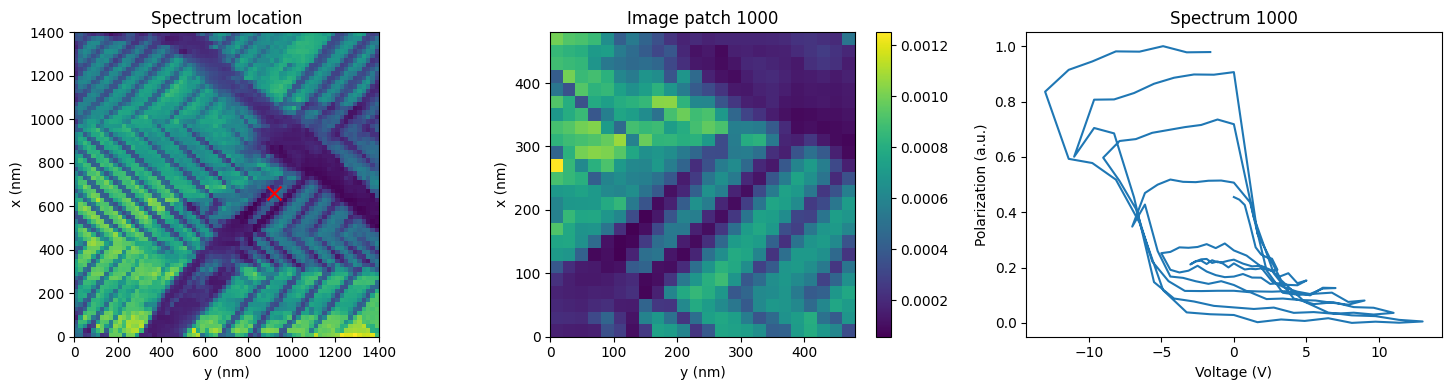

In [121]:
idx = 1000

x, y = coordinates[idx]
x_nm = x * nm_per_pixel
y_nm = y * nm_per_pixel


fig, ax = plt.subplots(1, 3, figsize=(15,4))

# Full structure image 
ax[0].imshow(struc_img, origin="lower",
             extent=[0, struc_img.shape[1]*nm_per_pixel,
                     0, struc_img.shape[0]*nm_per_pixel])
ax[0].scatter(y*nm_per_pixel, x*nm_per_pixel, marker="x", s=100, c="r")
ax[0].set_title(f"Spectrum location")
ax[0].set_xlabel("y (nm)")
ax[0].set_ylabel("x (nm)")

# Image patch
im = ax[1].imshow(images[idx], origin="lower",
                  extent=[0, images[idx].shape[1]*nm_per_pixel,
                          0, images[idx].shape[0]*nm_per_pixel])
fig.colorbar(im, ax=ax[1])
ax[1].set_title(f"Image patch {idx}")
ax[1].set_xlabel("y (nm)")
ax[1].set_ylabel("x (nm)")

# Spectrum
ax[2].plot(v_step, spectra[idx])
ax[2].set_xlabel("Voltage (V)")
ax[2].set_ylabel("Polarization (a.u.)")
ax[2].set_title(f"Spectrum {idx}")

plt.tight_layout()
plt.show()


In [94]:
print(struc_img.shape)
print(coordinates[idx])

(70, 70)
[13 16]


In [95]:
# coordinates are reversed.
swap_coordinates = coordinates.copy()
swap_coordinates = swap_coordinates[:, [1, 0]]
swap_coordinates.shape

(2116, 2)

In [96]:
images_all = images.copy()
images_all = (images_all - images_all.min()) / (images_all.max() - images_all.min())
spectra_all = spectra.copy()
swap_coordinates_all = swap_coordinates.copy()
from sklearn.model_selection import train_test_split

images_train, images_test, spectra_train, spectra_test, s_coords_train, s_coords_test = train_test_split(
images_all, spectra_all, swap_coordinates_all, train_size = 0.7, random_state=42
)

initial_trainsize = images_train.shape[0]
print("images_train shape:", images_train.shape)
print("images_test shape:", images_test.shape)
print("spectra_train shape:", spectra_train.shape)
print("spectra_test shape:", spectra_test.shape)

images_train shape: (1481, 24, 24)
images_test shape: (635, 24, 24)
spectra_train shape: (1481, 192)
spectra_test shape: (635, 192)


In [97]:
print("min:", images_all.min())
print("max:", images_all.max())
print("min:", spectra_all.min())
print("max:", spectra_all.max())

min: 0.0
max: 1.0
min: 0.0
max: 1.0


In [98]:
images, spectra, scale_coordinates = append_multiscale_data(images_all, spectra_all, scales=np.arange(WS_init, WS, d_WS),
                                                            coordinates=swap_coordinates_all,
                                                            append_image_type=append_image_type)

Augmented images shape: (12696, 24, 24), Augmented spectra shape: (12696, 192), Augmented coordinates shape: (12696, 3)


In [99]:
images_tr_aug, spectra_tr_aug, _ = append_multiscale_data(images_train, spectra_train, scales=np.arange(WS_init, WS, d_WS),
                                                            coordinates=s_coords_train,
                                                            append_image_type=append_image_type)



images_test_aug, spectra_test_aug, _ = append_multiscale_data(images_test, spectra_test, scales=np.arange(WS_init, WS, d_WS),
                                                            coordinates=s_coords_test,
                                                            append_image_type=append_image_type)

print("images_train shape:", images_tr_aug.shape)
print("images_test shape:", images_test_aug.shape)

Augmented images shape: (8886, 24, 24), Augmented spectra shape: (8886, 192), Augmented coordinates shape: (8886, 3)
Augmented images shape: (3810, 24, 24), Augmented spectra shape: (3810, 192), Augmented coordinates shape: (3810, 3)
images_train shape: (8886, 24, 24)
images_test shape: (3810, 24, 24)


In [100]:
print("images shape:", images.shape)
print("spectra shape:", spectra.shape)
in_dim = images[0].shape  # Input dimensions (image height and width)
out_dim = len(spectra[0])  # Output dimensions (spectra length)

images shape: (12696, 24, 24)
spectra shape: (12696, 192)


In [101]:
# ----------------------------
# 2) Fit FNO_im2spec model
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if model_type == 'FNO':

  # FNO_im2spec mode. Trains better with interpolation based augmentation.
  imspec_model = FNO_im2spec(
      target_size=out_dim,
      latent_dim=latent_dim,
      hidden_channels=32,
      n_modes=(16, 16),
      n_layers=4,
      use_swa = use_swa,
      last_swa_epochs = last_swa_epochs,
  ).to(device)

elif model_type == 'im2spec':
  # Use this normal im2spec. Augmentation by padding works better here.
  imspec_model = im2spec(feature_size=in_dim, target_size=out_dim, latent_dim=latent_dim).to(device)
elif model_type == 'im2spec_attn':
  imspec_model = im2spec_attn(feature_size=in_dim, target_size=out_dim, latent_dim=latent_dim).to(device)



else:
  raise ValueError(f"Unknown model type: {model_type}")

 50%|█████     | 101/200 [00:42<00:44,  2.21it/s, train_loss=0.0153, val_loss=0.0216]

SWA triggered at epoch 100


 59%|█████▉    | 118/200 [00:49<00:34,  2.38it/s, train_loss=0.0143, val_loss=0.0212]


Early stopping triggered after 10 epochs!


/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


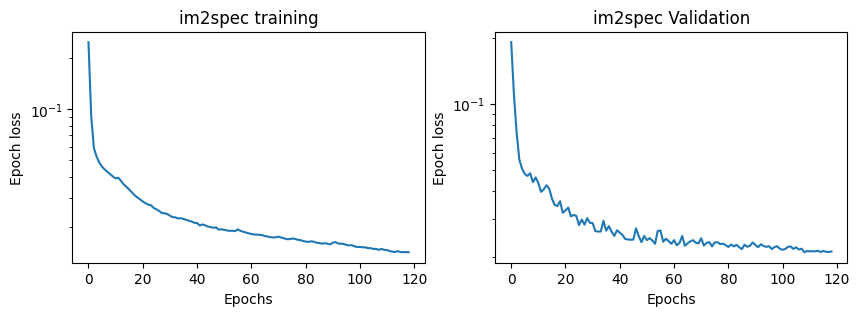

im2spec final train loss: 0.014256480149924755
im2spec final internal val loss: 0.02123808115720749
im2spec held-out test loss: 0.019467370584607124


In [102]:
im2spec_training_dataset = TensorDataset(
    torch.tensor(images_tr_aug, dtype=torch.float32),
    torch.tensor(spectra_tr_aug, dtype=torch.float32),
)

im2spec_val_dataset = TensorDataset(
    torch.tensor(images_test_aug, dtype=torch.float32),
    torch.tensor(spectra_test_aug, dtype=torch.float32),
)

# train_model creates its own validation split from the dataset above.
# Keep images_test/spectra_test as an external held-out test set.

plot_im2spec_training = True

imspec_model, im2spec_train_loss, im2spec_val_loss = train_model(
    imspec_model,
    im2spec_training_dataset,
    n_batches=6,
    lr=1e-3,
    patience=10,
    n_epochs=n_epochs_im2spec,
    partial_train=False,
    val_dataset=im2spec_val_dataset,  # if not provided, train_model will split off its own validation set from the training dataset
    use_swa = True,
    last_swa_epochs = last_swa_epochs
)

if plot_im2spec_training:
    plot_only_training_loss([im2spec_train_loss], [im2spec_val_loss])

imspec_model.eval()
with torch.no_grad():
    x_test = torch.tensor(images_test, dtype=torch.float32, device=device)
    y_test = torch.tensor(spectra_test, dtype=torch.float32, device=device)
    test_pred = imspec_model.predict(x_test)
    im2spec_test_loss = torch.nn.functional.mse_loss(test_pred, y_test).item()

print("im2spec final train loss:", im2spec_train_loss[-1])
print("im2spec final internal val loss:", im2spec_val_loss[-1])
print("im2spec held-out test loss:", im2spec_test_loss)

In [103]:
# ----------------------------
# 3) Build error targets using err_estimation
# ----------------------------
error_mean, error_std, error_vector = err_estimation(imspec_model, images_tr_aug, spectra_tr_aug, error_type=error_type)
error_targets = error_mean.astype(np.float32).reshape(-1, 1)
error_norm = Norm_0to1(data=error_targets)
normed_error_targets = error_norm.normalize()

print("error_mean shape:", error_mean.shape)
print("error_vector shape:", error_vector.shape)
print("error_targets shape:", error_targets.shape)


# ----------------------------
# 4) Fuse im2spec encoder with CustomDecoder
# ----------------------------
with torch.no_grad():
    latent_dim = imspec_model.encoder(torch.tensor(images[:1], dtype=torch.float32, device=device).unsqueeze(1)).shape[1]

error_model = CustomDecoder(encoder=imspec_model.encoder, embed_dim=latent_dim, target_size=1).to(device)

error_mean shape: (8886,)
error_vector shape: (8886, 192)
error_targets shape: (8886, 1)


 50%|█████     | 101/200 [00:30<00:29,  3.40it/s, train_loss=0.0105, val_loss=0.0107]

SWA triggered at epoch 100


 62%|██████▎   | 125/200 [00:38<00:22,  3.29it/s, train_loss=0.0083, val_loss=0.0106]


Early stopping triggered after 10 epochs!
error model final train loss: 0.008269097855580705
error model final val loss: 0.010632717050611973


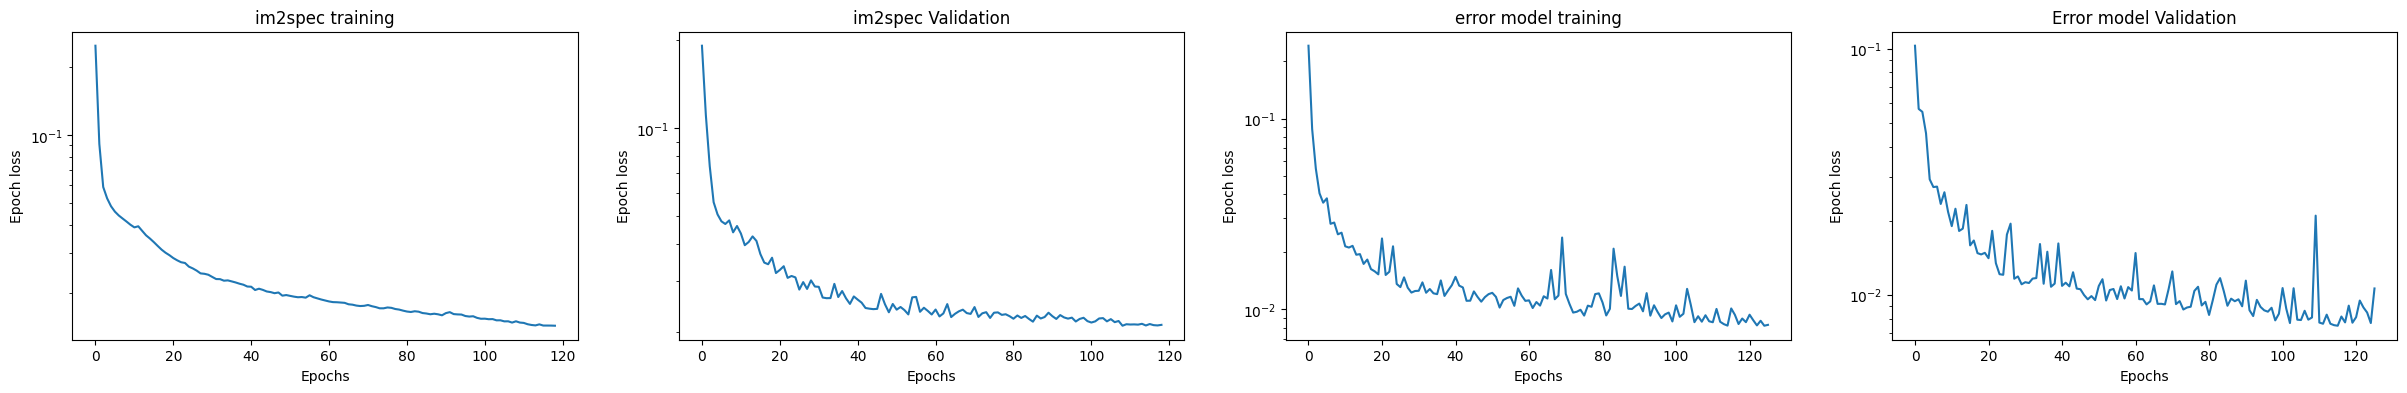

In [104]:
# ----------------------------
# 5) Train error model on images and estimated errors
# ----------------------------



error_training_dataset = TensorDataset(
    torch.tensor(images_tr_aug, dtype=torch.float32),
    torch.tensor(normed_error_targets, dtype=torch.float32),
)


error_model, error_train_loss, error_val_loss = train_model(
    error_model,
    error_training_dataset,
    n_batches=6,
    lr=1e-3,
    patience=10,
    val_dataset=None,  # if not provided, train_model will split off its own validation set from the training dataset
    n_epochs=n_epochs_error,
    partial_train=True,
    use_swa = True,
    last_swa_epochs = last_swa_epochs
)
error_model.eval()
# with torch.no_grad():
#     x_test_error = torch.tensor(images_test_aug, dtype=torch.float32, device=device)
#     y_test_error = torch.tensor(error_mean, dtype=torch.float32, device=device)
#     test_pred_error = error_model.predict(x_test_error)
#     error_test_loss = torch.nn.functional.mse_loss(test_pred_error, y_test_error).item()

print("error model final train loss:", error_train_loss[-1])
print("error model final val loss:", error_val_loss[-1])


plot_training_loss([im2spec_train_loss], [im2spec_val_loss], error_train_loss, error_val_loss)

In [105]:
#Predict errors on the entire dataset using the trained error model
normed_predicted_errors = predict_spectra(error_model, images, ensemble=False)
print("normed_predicted_errors shape:", np.asarray(normed_predicted_errors).shape)
predicted_errors = error_norm.denormalize(normed_predicted_errors).reshape(-1)
predicted_errors = np.clip(predicted_errors, 0, None)
print("predicted_errors shape:", np.asarray(predicted_errors).shape)
print("predicted_errors range:", float(np.min(predicted_errors)), float(np.max(predicted_errors)))

normed_predicted_errors shape: (12696,)
predicted_errors shape: (12696,)
predicted_errors range: 0.0 0.18471547961235046


In [106]:
from nnerror.training_functions import distance_acq_fn
#beta=0 is explotation. aq_fn is inverse to errors
aq_ind_scaled, aq_fn_scaled = distance_acq_fn(predicted_errors, beta = 1, lambda_ = 1, sample_next_points = 1, exclude_indices = [])
print(aq_fn_scaled.shape)

(12696,)


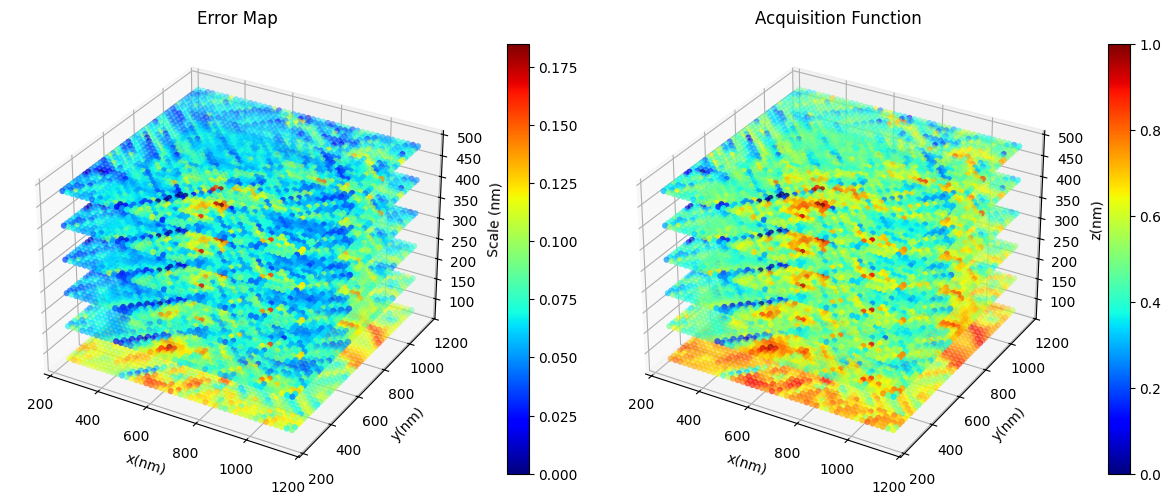

In [107]:
plot_error_prediction_3d(predicted_errors.reshape(-1, 1), aq_fn_scaled, scale_coordinates, aq_ind_scaled, alpha_scale = False, colormap = 'jet')

IndexError: index 4899 is out of bounds for axis 0 with size 2116

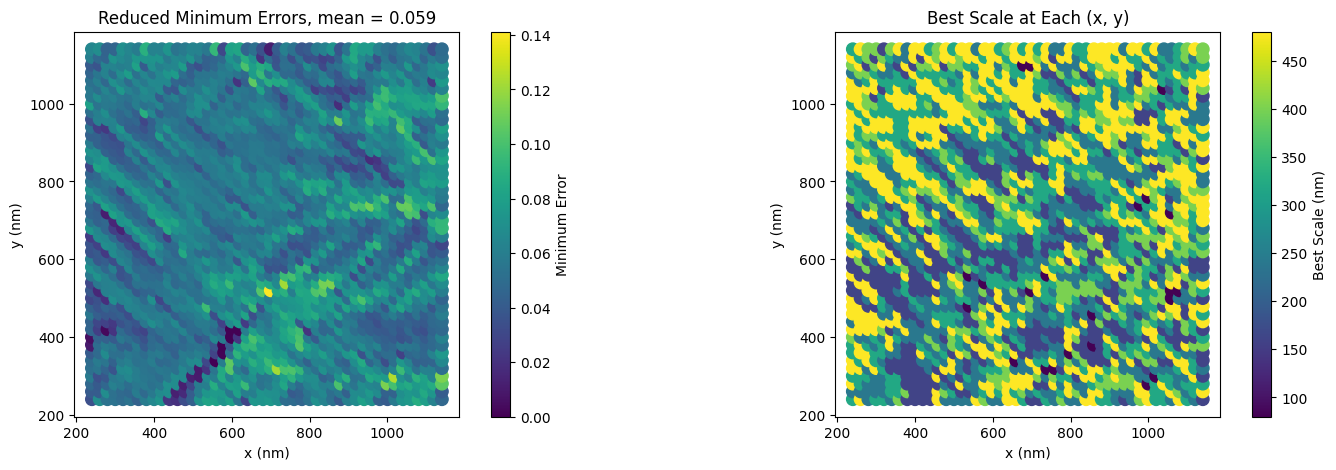

In [109]:
plot_reduced_errors_and_scales(*reduce_errors_and_coords(predicted_errors, scale_coordinates), aq_indices=aq_ind_scaled, nm_per_pixel=nm_per_pixel)

In [ ]:
print(len(error_mean))
print(len(aq_fn_scaled))
print(coordinates.shape)

6060
8664
(1444, 2)


ACQUISITION 

In [ ]:
WS = 24
WS_init = 4
d_WS = 4
n_epochs_im2spec = 100
n_epochs_error = 100
error_type = "L1" # "L1", "L2", or "cos"

#append_image_type = 'interpolate'
use_swa = True
latent_dim = 5
last_swa_epochs = 0.1

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

def default_append_image_type(model_type):
    if model_type in ("im2spec", "im2spec_attn"):
        return "pad"
    return "interpolate"
model_types = ['im2spec', 'im2spec_attn', 'FNO', 'FNO_attn']
append_image_types = [default_append_image_type(model_type) for model_type in model_types] #pad, interpolate

scale_type = "multi_scale"  # "single_scale" or "multi_scale"

In [ ]:
def split_augment(train_size, images, spectra, swap_coordinates, WS_init, WS, d_WS, append_image_type, random_state = 42):

  images_train, images_test, spectra_train, spectra_test, s_coords_train, s_coords_test = train_test_split(
  images, spectra, swap_coordinates, train_size = train_size, random_state=random_state)



  images_tr_aug, spectra_tr_aug, _ = append_multiscale_data(images_train, spectra_train, scales=np.arange(WS_init, WS, d_WS),
                                                              coordinates=s_coords_train,
                                                              append_image_type=append_image_type)



  images_test_aug, spectra_test_aug, _ = append_multiscale_data(images_test, spectra_test, scales=np.arange(WS_init, WS, d_WS),
                                                              coordinates=s_coords_test,
                                                              append_image_type=append_image_type)

  return images_tr_aug, images_test_aug, spectra_tr_aug, spectra_test_aug

In [ ]:
WS = 24
WS_init = 4
d_WS = 4
n_epochs_im2spec = 100
n_epochs_error = 100
error_type = "L1" # "L1", "L2", or "cos"
model_type = 'FNO'
append_image_type = "pad" if model_type in ['im2spec', 'im2spec_attn'] else "interpolate"#append_image_type = 'interpolate'
use_swa = True
latent_dim = 5
last_swa_epochs = 0.1

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [ ]:

# initialize variables for the acquisition loop
acquisition_iterations = 20  # number of iterations
num_new_points = 5  # points per iteration
acquisition_method = "random"  # or "random"

len(images): 8664
len(indices_train): 144
len(indices_test): 1300

Active Learning Iteration 1/20
Augmented images shape: (864, 32, 32), Augmented spectra shape: (864, 192), Augmented coordinates shape: (864, 3)
Augmented images shape: (7800, 32, 32), Augmented spectra shape: (7800, 192), Augmented coordinates shape: (7800, 3)
Current augmented train data: 864, Current augmented test data: 7800


 91%|█████████ | 91/100 [00:30<00:03,  2.71it/s, train_loss=0.0000, val_loss=0.0000]

SWA triggered at epoch 90


 92%|█████████▏| 92/100 [00:12<00:01,  7.49it/s, train_loss=0.0365, val_loss=0.0383]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:13<00:00,  7.47it/s, train_loss=0.0369, val_loss=0.0412]


Augmented images shape: (8664, 32, 32), Augmented spectra shape: (8664, 192), Augmented coordinates shape: (8664, 3)


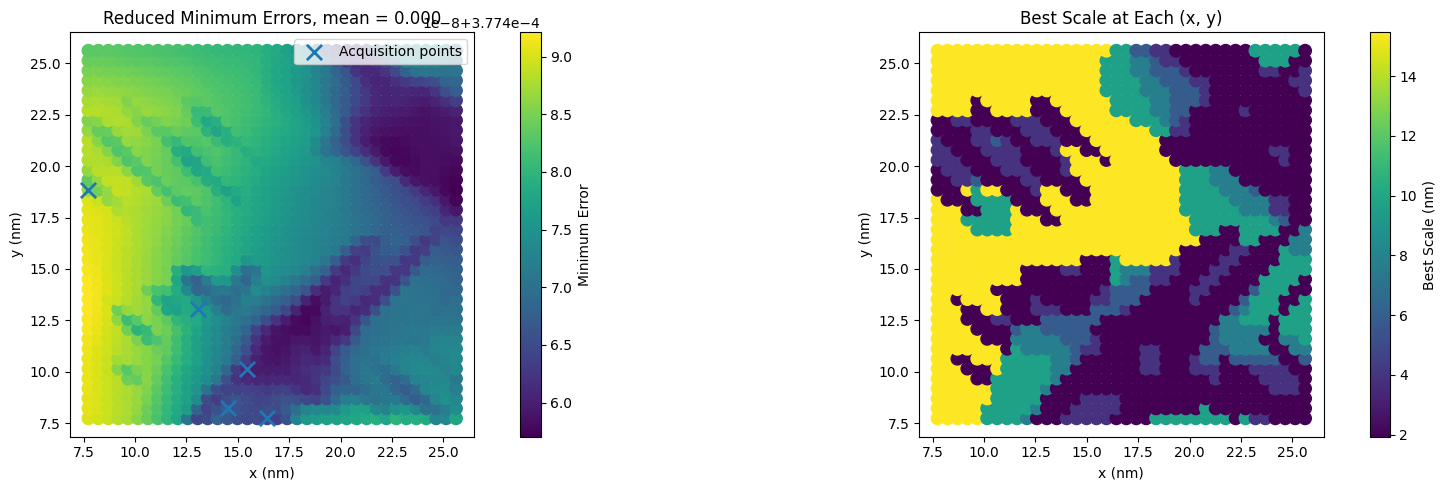

Train indices set size: 149, Test indices set size: 1295

Active Learning Iteration 2/20
Augmented images shape: (894, 32, 32), Augmented spectra shape: (894, 192), Augmented coordinates shape: (894, 3)
Augmented images shape: (7770, 32, 32), Augmented spectra shape: (7770, 192), Augmented coordinates shape: (7770, 3)
Current augmented train data: 894, Current augmented test data: 7770


 91%|█████████ | 91/100 [00:31<00:03,  2.57it/s, train_loss=0.0000, val_loss=0.0000]

SWA triggered at epoch 90


 92%|█████████▏| 92/100 [00:12<00:01,  7.43it/s, train_loss=0.0411, val_loss=0.0332]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:13<00:00,  7.50it/s, train_loss=0.0469, val_loss=0.0341]


Augmented images shape: (8664, 32, 32), Augmented spectra shape: (8664, 192), Augmented coordinates shape: (8664, 3)


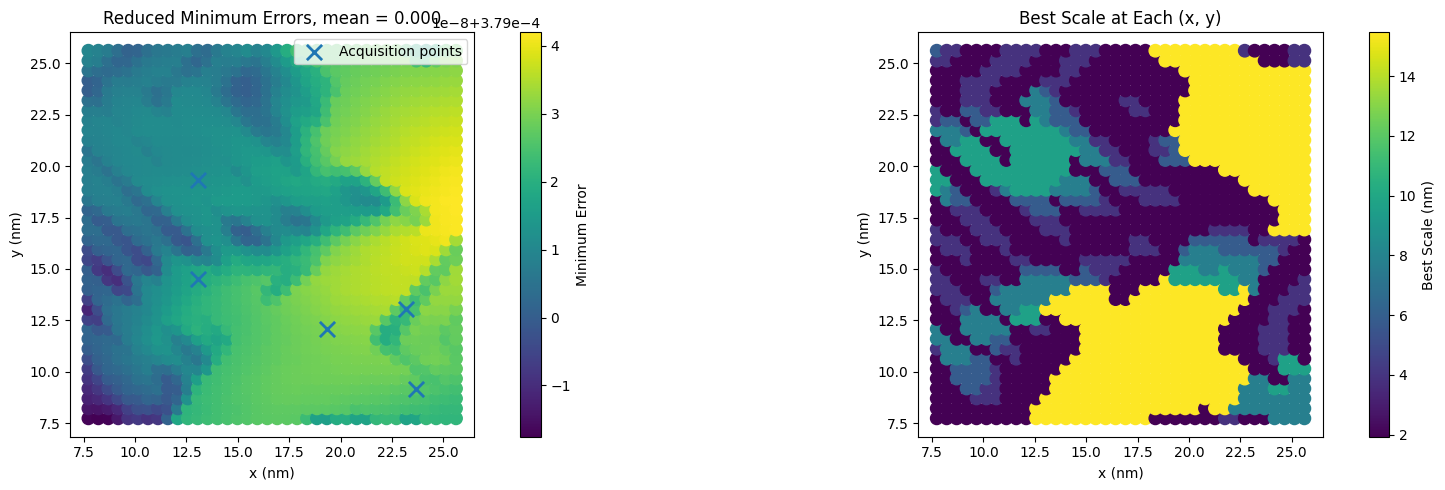

Train indices set size: 154, Test indices set size: 1290

Active Learning Iteration 3/20
Augmented images shape: (924, 32, 32), Augmented spectra shape: (924, 192), Augmented coordinates shape: (924, 3)
Augmented images shape: (7740, 32, 32), Augmented spectra shape: (7740, 192), Augmented coordinates shape: (7740, 3)
Current augmented train data: 924, Current augmented test data: 7740


 91%|█████████ | 91/100 [00:30<00:02,  3.05it/s, train_loss=0.0000, val_loss=0.0000]

SWA triggered at epoch 90


 92%|█████████▏| 92/100 [00:12<00:01,  7.45it/s, train_loss=0.0329, val_loss=0.0403]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:13<00:00,  7.51it/s, train_loss=0.0304, val_loss=0.0434]


Augmented images shape: (8664, 32, 32), Augmented spectra shape: (8664, 192), Augmented coordinates shape: (8664, 3)


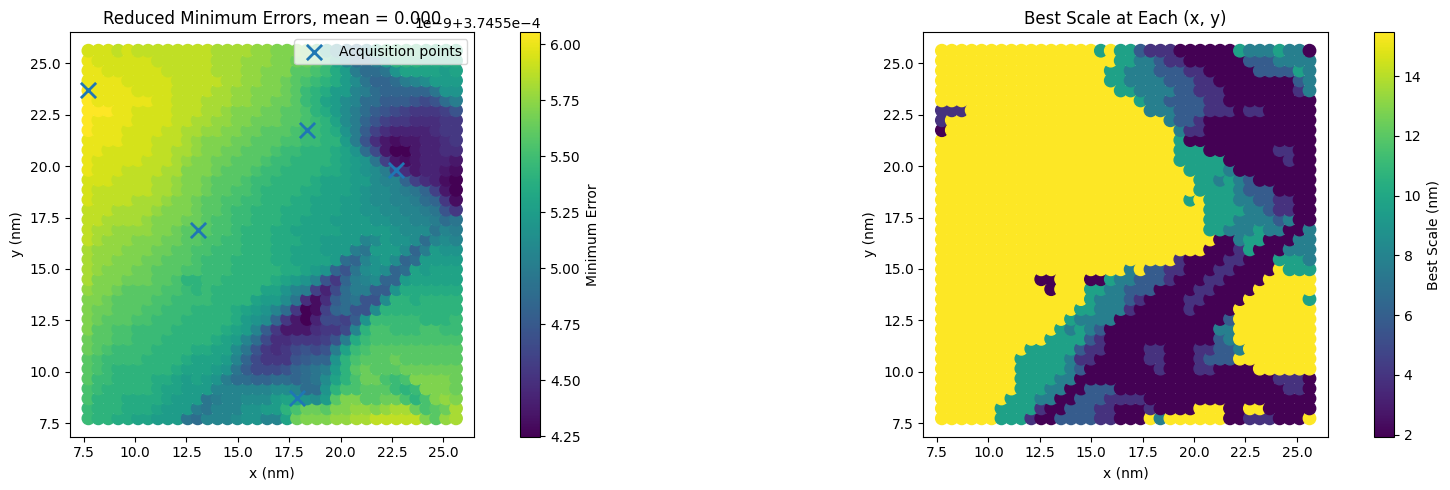

Train indices set size: 159, Test indices set size: 1285

Active Learning Iteration 4/20
Augmented images shape: (954, 32, 32), Augmented spectra shape: (954, 192), Augmented coordinates shape: (954, 3)
Augmented images shape: (7710, 32, 32), Augmented spectra shape: (7710, 192), Augmented coordinates shape: (7710, 3)
Current augmented train data: 954, Current augmented test data: 7710


 91%|█████████ | 91/100 [00:31<00:03,  2.94it/s, train_loss=0.0000, val_loss=0.0000]

SWA triggered at epoch 90


 92%|█████████▏| 92/100 [00:12<00:01,  7.21it/s, train_loss=0.0329, val_loss=0.0400]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:13<00:00,  7.40it/s, train_loss=0.0333, val_loss=0.0446]


Augmented images shape: (8664, 32, 32), Augmented spectra shape: (8664, 192), Augmented coordinates shape: (8664, 3)


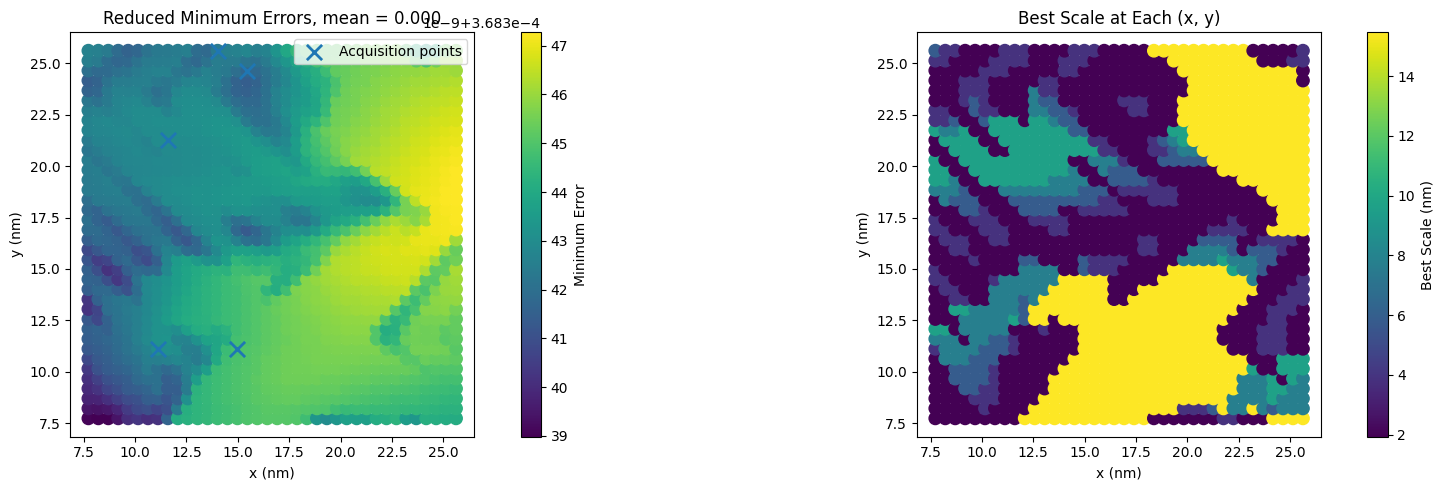

Train indices set size: 164, Test indices set size: 1280

Active Learning Iteration 5/20
Augmented images shape: (984, 32, 32), Augmented spectra shape: (984, 192), Augmented coordinates shape: (984, 3)
Augmented images shape: (7680, 32, 32), Augmented spectra shape: (7680, 192), Augmented coordinates shape: (7680, 3)
Current augmented train data: 984, Current augmented test data: 7680


 91%|█████████ | 91/100 [00:31<00:03,  2.56it/s, train_loss=0.0000, val_loss=0.0000]

SWA triggered at epoch 90


 92%|█████████▏| 92/100 [00:12<00:01,  7.27it/s, train_loss=0.0391, val_loss=0.0405]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:13<00:00,  7.44it/s, train_loss=0.0434, val_loss=0.0391]


Augmented images shape: (8664, 32, 32), Augmented spectra shape: (8664, 192), Augmented coordinates shape: (8664, 3)


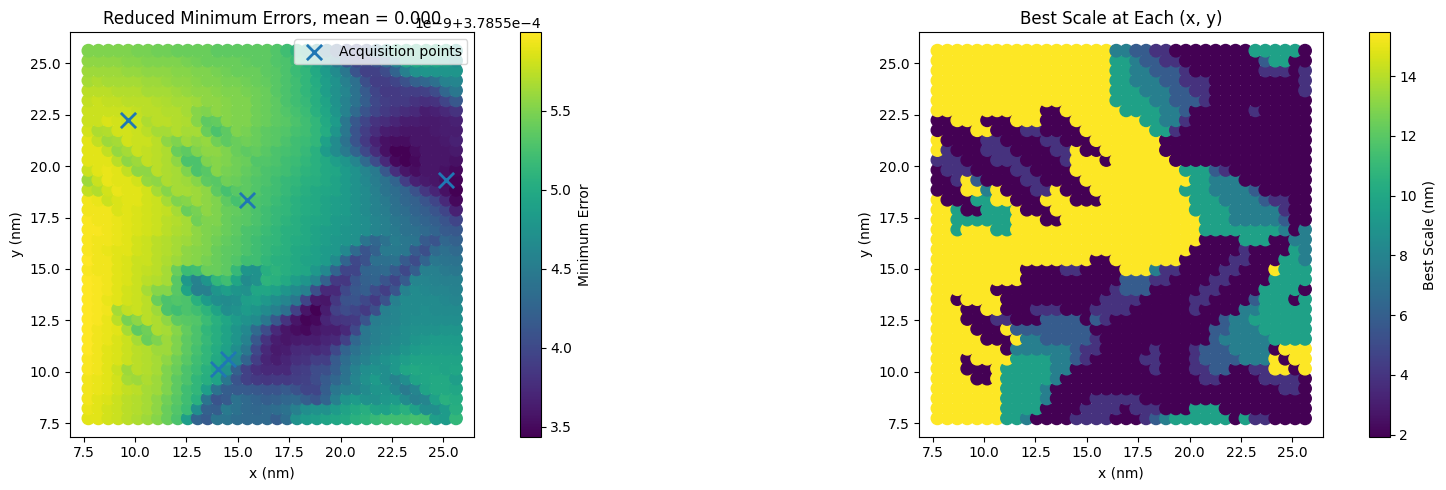

Train indices set size: 169, Test indices set size: 1275

Active Learning Iteration 6/20
Augmented images shape: (1014, 32, 32), Augmented spectra shape: (1014, 192), Augmented coordinates shape: (1014, 3)
Augmented images shape: (7650, 32, 32), Augmented spectra shape: (7650, 192), Augmented coordinates shape: (7650, 3)
Current augmented train data: 1014, Current augmented test data: 7650


 91%|█████████ | 91/100 [00:31<00:03,  2.99it/s, train_loss=0.0000, val_loss=0.0000]

SWA triggered at epoch 90


 92%|█████████▏| 92/100 [00:12<00:01,  7.45it/s, train_loss=0.0413, val_loss=0.0348]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:13<00:00,  7.46it/s, train_loss=0.0508, val_loss=0.0348]


Augmented images shape: (8664, 32, 32), Augmented spectra shape: (8664, 192), Augmented coordinates shape: (8664, 3)


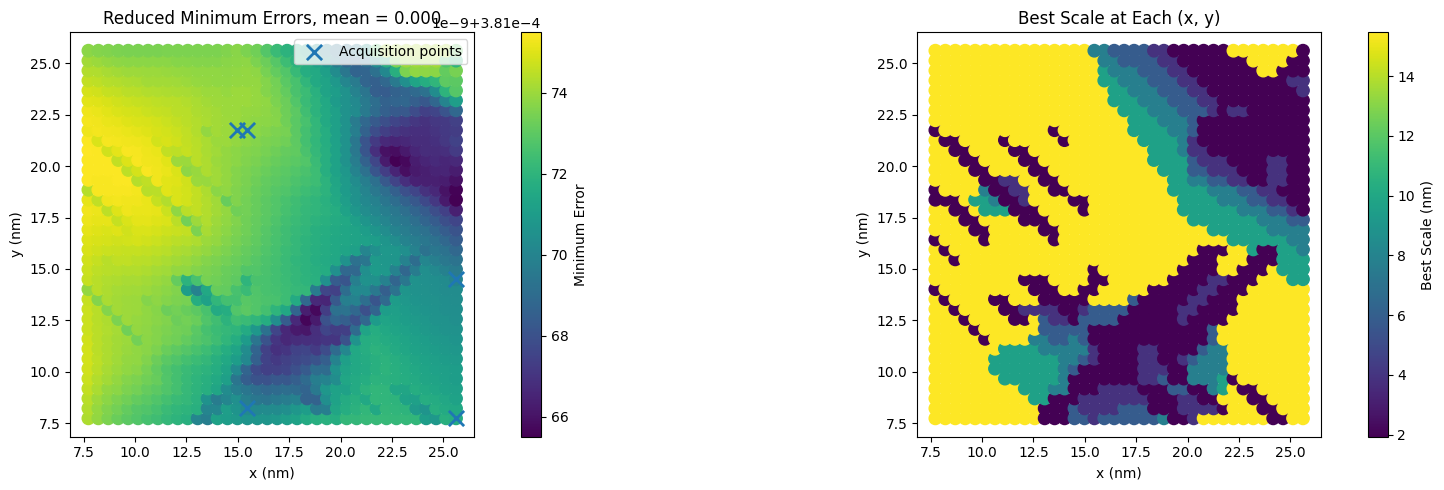

Train indices set size: 174, Test indices set size: 1270

Active Learning Iteration 7/20
Augmented images shape: (1044, 32, 32), Augmented spectra shape: (1044, 192), Augmented coordinates shape: (1044, 3)
Augmented images shape: (7620, 32, 32), Augmented spectra shape: (7620, 192), Augmented coordinates shape: (7620, 3)
Current augmented train data: 1044, Current augmented test data: 7620


 91%|█████████ | 91/100 [00:30<00:02,  3.06it/s, train_loss=0.0000, val_loss=0.0000]

SWA triggered at epoch 90


 92%|█████████▏| 92/100 [00:12<00:01,  7.39it/s, train_loss=0.0446, val_loss=0.0437]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:13<00:00,  7.39it/s, train_loss=0.0587, val_loss=0.0471]


Augmented images shape: (8664, 32, 32), Augmented spectra shape: (8664, 192), Augmented coordinates shape: (8664, 3)


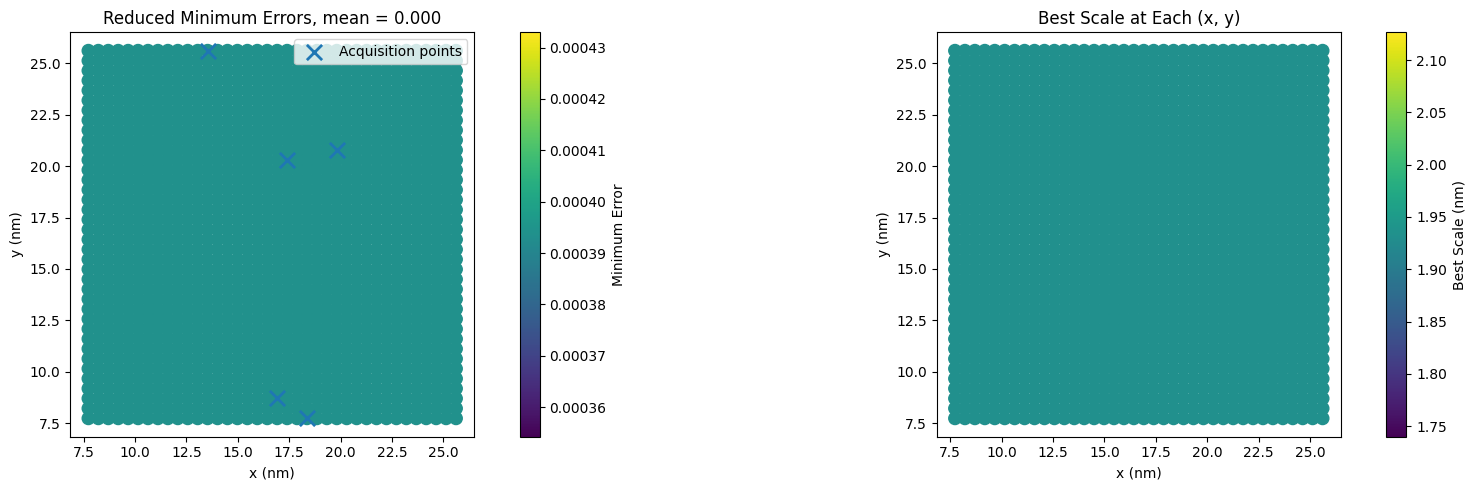

Train indices set size: 179, Test indices set size: 1265

Active Learning Iteration 8/20
Augmented images shape: (1074, 32, 32), Augmented spectra shape: (1074, 192), Augmented coordinates shape: (1074, 3)
Augmented images shape: (7590, 32, 32), Augmented spectra shape: (7590, 192), Augmented coordinates shape: (7590, 3)
Current augmented train data: 1074, Current augmented test data: 7590


 91%|█████████ | 91/100 [00:31<00:02,  3.03it/s, train_loss=0.0000, val_loss=0.0000]

SWA triggered at epoch 90


 92%|█████████▏| 92/100 [00:12<00:01,  7.15it/s, train_loss=0.0415, val_loss=0.0377]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:13<00:00,  7.31it/s, train_loss=0.0462, val_loss=0.0367]


Augmented images shape: (8664, 32, 32), Augmented spectra shape: (8664, 192), Augmented coordinates shape: (8664, 3)


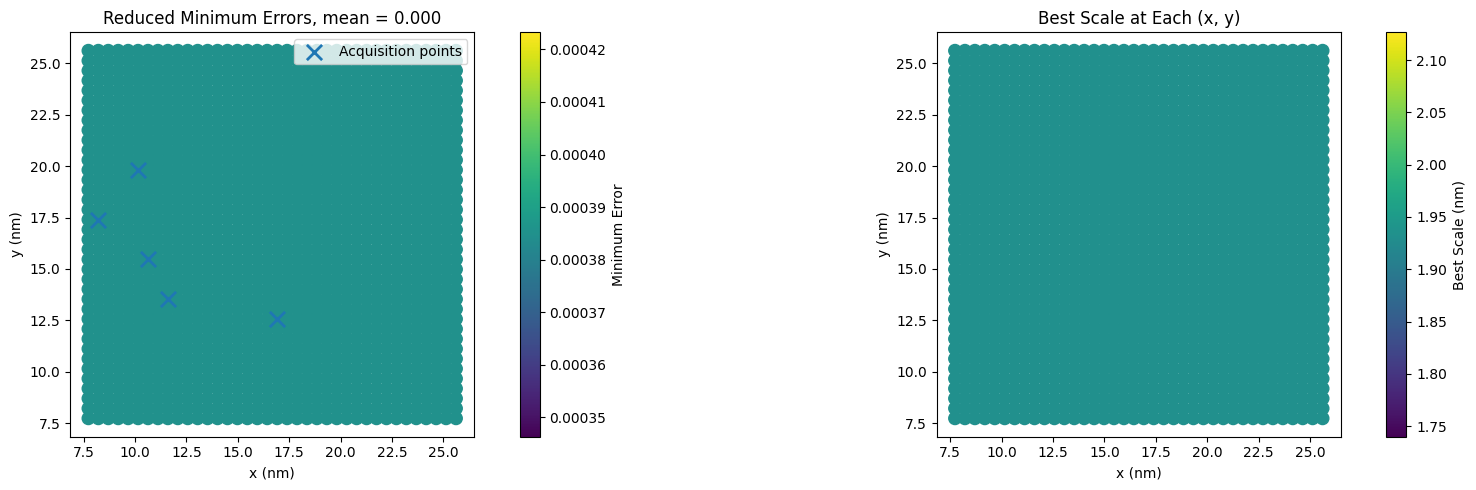

Train indices set size: 184, Test indices set size: 1260

Active Learning Iteration 9/20
Augmented images shape: (1104, 32, 32), Augmented spectra shape: (1104, 192), Augmented coordinates shape: (1104, 3)
Augmented images shape: (7560, 32, 32), Augmented spectra shape: (7560, 192), Augmented coordinates shape: (7560, 3)
Current augmented train data: 1104, Current augmented test data: 7560


 91%|█████████ | 91/100 [00:31<00:02,  3.02it/s, train_loss=0.0000, val_loss=0.0000]

SWA triggered at epoch 90


 92%|█████████▏| 92/100 [00:12<00:01,  7.32it/s, train_loss=0.0446, val_loss=0.0403]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:13<00:00,  7.27it/s, train_loss=0.0431, val_loss=0.0384]


Augmented images shape: (8664, 32, 32), Augmented spectra shape: (8664, 192), Augmented coordinates shape: (8664, 3)


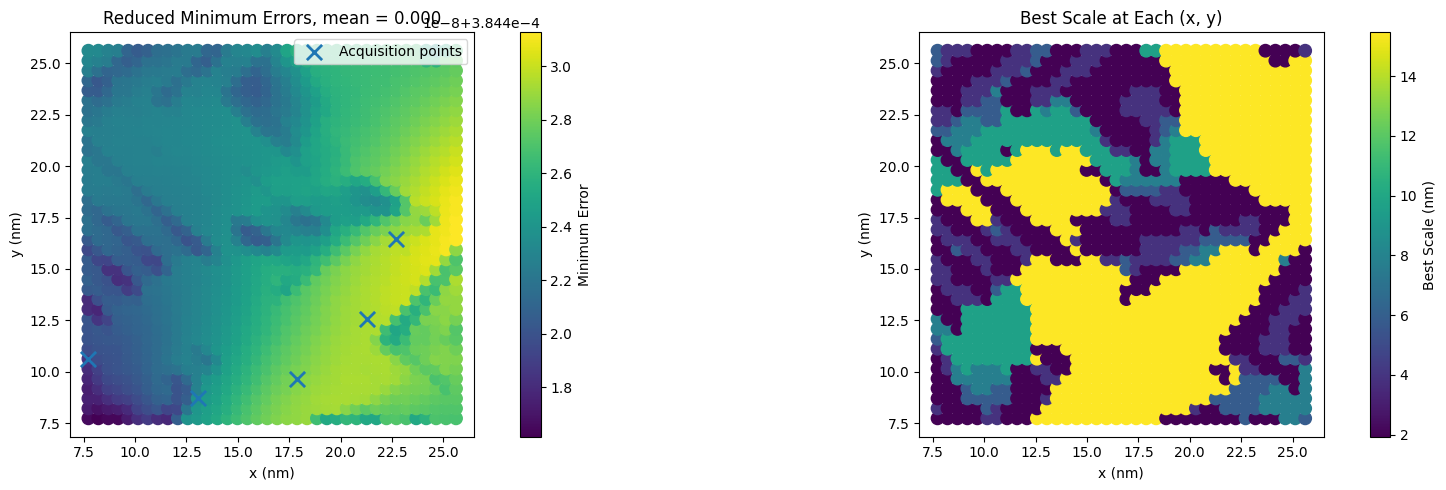

Train indices set size: 189, Test indices set size: 1255

Active Learning Iteration 10/20
Augmented images shape: (1134, 32, 32), Augmented spectra shape: (1134, 192), Augmented coordinates shape: (1134, 3)
Augmented images shape: (7530, 32, 32), Augmented spectra shape: (7530, 192), Augmented coordinates shape: (7530, 3)
Current augmented train data: 1134, Current augmented test data: 7530


 91%|█████████ | 91/100 [00:30<00:02,  3.03it/s, train_loss=0.0000, val_loss=0.0000]

SWA triggered at epoch 90


 92%|█████████▏| 92/100 [00:12<00:01,  7.36it/s, train_loss=0.0380, val_loss=0.0394]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:13<00:00,  7.35it/s, train_loss=0.0461, val_loss=0.0412]


Augmented images shape: (8664, 32, 32), Augmented spectra shape: (8664, 192), Augmented coordinates shape: (8664, 3)


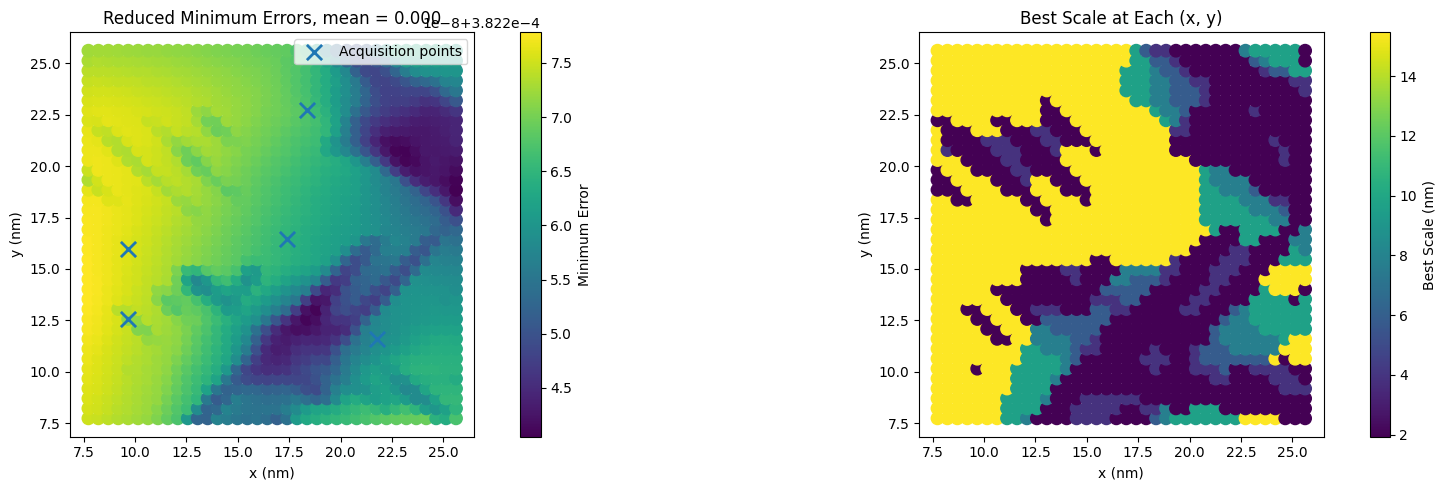

Train indices set size: 194, Test indices set size: 1250

Active Learning Iteration 11/20
Augmented images shape: (1164, 32, 32), Augmented spectra shape: (1164, 192), Augmented coordinates shape: (1164, 3)
Augmented images shape: (7500, 32, 32), Augmented spectra shape: (7500, 192), Augmented coordinates shape: (7500, 3)
Current augmented train data: 1164, Current augmented test data: 7500


 91%|█████████ | 91/100 [00:30<00:02,  3.04it/s, train_loss=0.0000, val_loss=0.0000]

SWA triggered at epoch 90


 92%|█████████▏| 92/100 [00:12<00:01,  7.51it/s, train_loss=0.0407, val_loss=0.0478]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:13<00:00,  7.32it/s, train_loss=0.0364, val_loss=0.0453]


Augmented images shape: (8664, 32, 32), Augmented spectra shape: (8664, 192), Augmented coordinates shape: (8664, 3)


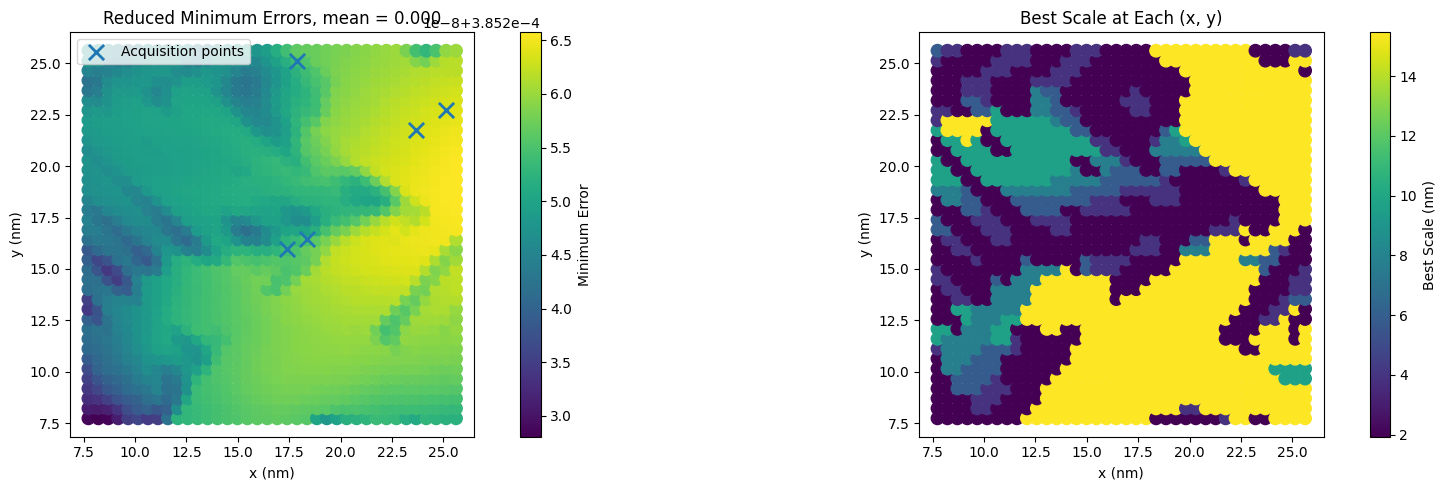

Train indices set size: 199, Test indices set size: 1245

Active Learning Iteration 12/20
Augmented images shape: (1194, 32, 32), Augmented spectra shape: (1194, 192), Augmented coordinates shape: (1194, 3)
Augmented images shape: (7470, 32, 32), Augmented spectra shape: (7470, 192), Augmented coordinates shape: (7470, 3)
Current augmented train data: 1194, Current augmented test data: 7470


 91%|█████████ | 91/100 [00:30<00:02,  3.09it/s, train_loss=0.0000, val_loss=0.0000]

SWA triggered at epoch 90


 92%|█████████▏| 92/100 [00:12<00:01,  7.17it/s, train_loss=0.0382, val_loss=0.0493]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:13<00:00,  7.30it/s, train_loss=0.0438, val_loss=0.0439]


Augmented images shape: (8664, 32, 32), Augmented spectra shape: (8664, 192), Augmented coordinates shape: (8664, 3)


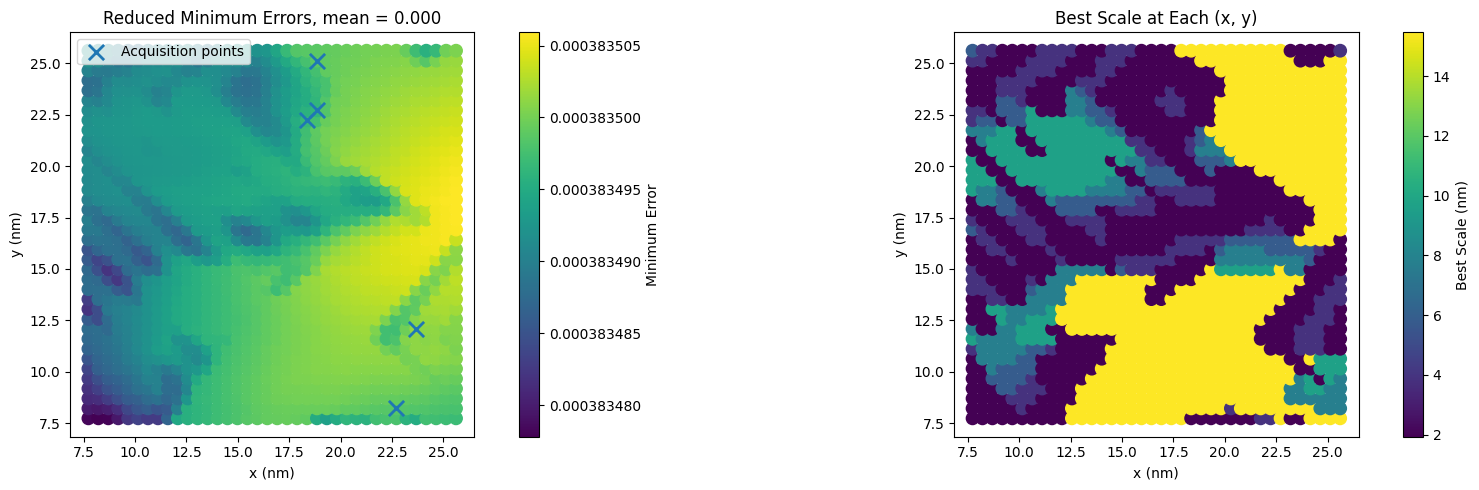

Train indices set size: 204, Test indices set size: 1240

Active Learning Iteration 13/20
Augmented images shape: (1224, 32, 32), Augmented spectra shape: (1224, 192), Augmented coordinates shape: (1224, 3)
Augmented images shape: (7440, 32, 32), Augmented spectra shape: (7440, 192), Augmented coordinates shape: (7440, 3)
Current augmented train data: 1224, Current augmented test data: 7440


 91%|█████████ | 91/100 [00:30<00:02,  3.10it/s, train_loss=0.0000, val_loss=0.0000]

SWA triggered at epoch 90


 92%|█████████▏| 92/100 [00:12<00:01,  7.07it/s, train_loss=0.0426, val_loss=0.0429]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:13<00:00,  7.26it/s, train_loss=0.0390, val_loss=0.0397]


Augmented images shape: (8664, 32, 32), Augmented spectra shape: (8664, 192), Augmented coordinates shape: (8664, 3)


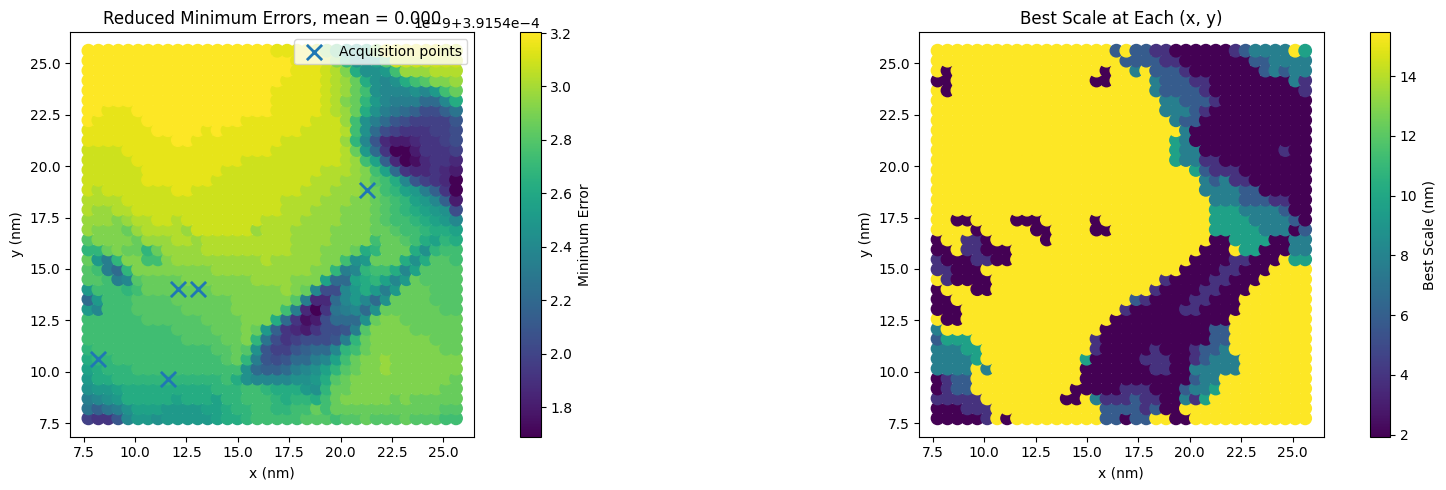

Train indices set size: 209, Test indices set size: 1235

Active Learning Iteration 14/20
Augmented images shape: (1254, 32, 32), Augmented spectra shape: (1254, 192), Augmented coordinates shape: (1254, 3)
Augmented images shape: (7410, 32, 32), Augmented spectra shape: (7410, 192), Augmented coordinates shape: (7410, 3)
Current augmented train data: 1254, Current augmented test data: 7410


 91%|█████████ | 91/100 [00:30<00:02,  3.06it/s, train_loss=0.0000, val_loss=0.0000]

SWA triggered at epoch 90


 92%|█████████▏| 92/100 [00:12<00:01,  7.26it/s, train_loss=0.0457, val_loss=0.0390]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:13<00:00,  7.26it/s, train_loss=0.0359, val_loss=0.0449]


Augmented images shape: (8664, 32, 32), Augmented spectra shape: (8664, 192), Augmented coordinates shape: (8664, 3)


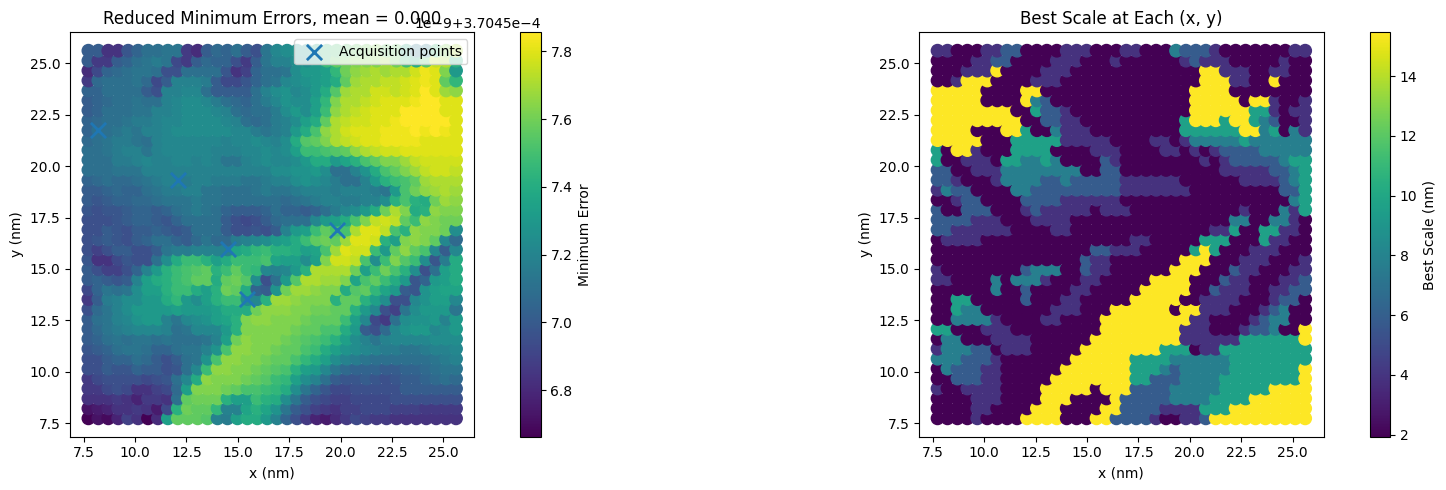

Train indices set size: 214, Test indices set size: 1230

Active Learning Iteration 15/20
Augmented images shape: (1284, 32, 32), Augmented spectra shape: (1284, 192), Augmented coordinates shape: (1284, 3)
Augmented images shape: (7380, 32, 32), Augmented spectra shape: (7380, 192), Augmented coordinates shape: (7380, 3)
Current augmented train data: 1284, Current augmented test data: 7380


 91%|█████████ | 91/100 [00:30<00:02,  3.10it/s, train_loss=0.0000, val_loss=0.0000]

SWA triggered at epoch 90


 92%|█████████▏| 92/100 [00:13<00:01,  7.37it/s, train_loss=0.0383, val_loss=0.0459]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:14<00:00,  7.08it/s, train_loss=0.0351, val_loss=0.0481]


Augmented images shape: (8664, 32, 32), Augmented spectra shape: (8664, 192), Augmented coordinates shape: (8664, 3)


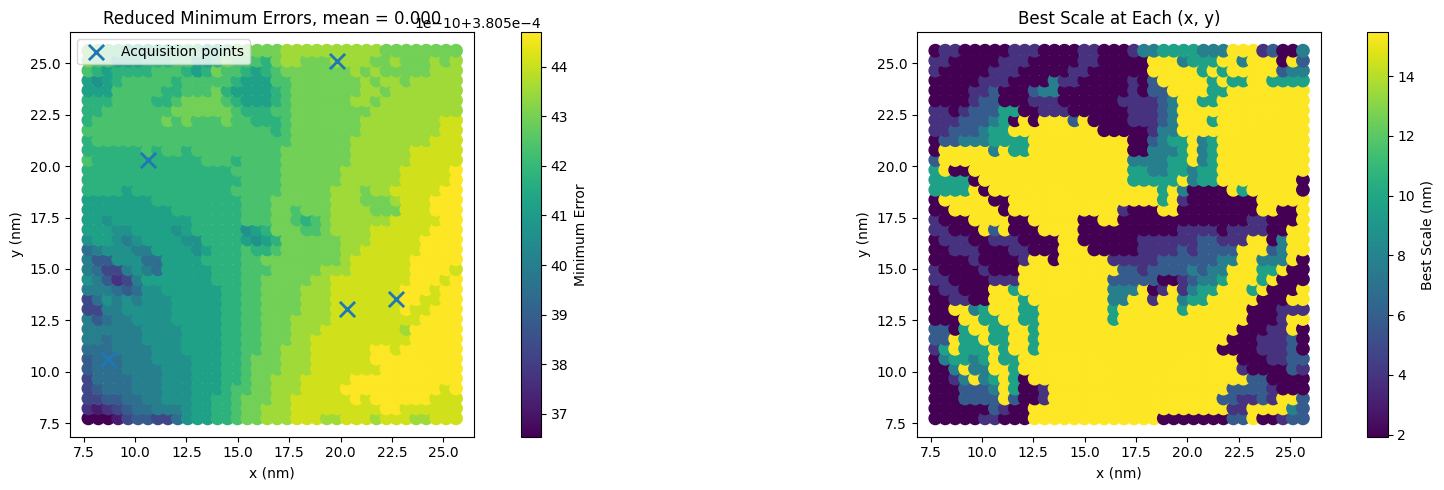

Train indices set size: 219, Test indices set size: 1225

Active Learning Iteration 16/20
Augmented images shape: (1314, 32, 32), Augmented spectra shape: (1314, 192), Augmented coordinates shape: (1314, 3)
Augmented images shape: (7350, 32, 32), Augmented spectra shape: (7350, 192), Augmented coordinates shape: (7350, 3)
Current augmented train data: 1314, Current augmented test data: 7350


 91%|█████████ | 91/100 [00:30<00:03,  2.67it/s, train_loss=0.0000, val_loss=0.0000]

SWA triggered at epoch 90


 92%|█████████▏| 92/100 [00:12<00:01,  7.05it/s, train_loss=0.0394, val_loss=0.0467]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:13<00:00,  7.17it/s, train_loss=0.0585, val_loss=0.0479]


Augmented images shape: (8664, 32, 32), Augmented spectra shape: (8664, 192), Augmented coordinates shape: (8664, 3)


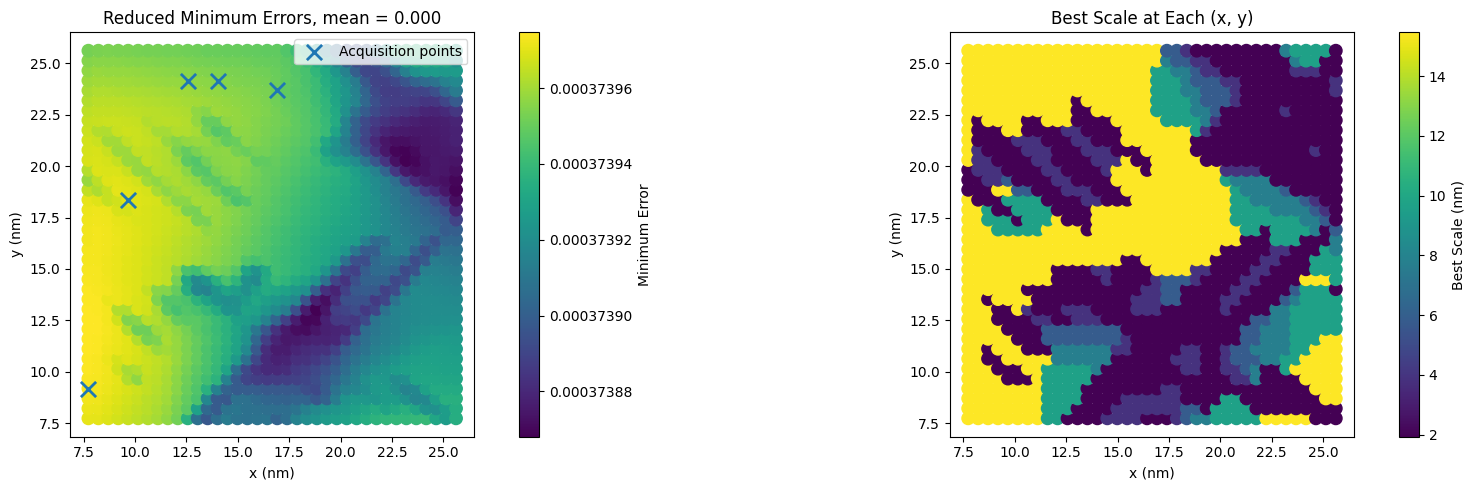

Train indices set size: 224, Test indices set size: 1220

Active Learning Iteration 17/20
Augmented images shape: (1344, 32, 32), Augmented spectra shape: (1344, 192), Augmented coordinates shape: (1344, 3)
Augmented images shape: (7320, 32, 32), Augmented spectra shape: (7320, 192), Augmented coordinates shape: (7320, 3)
Current augmented train data: 1344, Current augmented test data: 7320


 91%|█████████ | 91/100 [00:30<00:02,  3.04it/s, train_loss=0.0000, val_loss=0.0000]

SWA triggered at epoch 90


 92%|█████████▏| 92/100 [00:12<00:01,  7.19it/s, train_loss=0.0386, val_loss=0.0449]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:13<00:00,  7.16it/s, train_loss=0.0465, val_loss=0.0421]


Augmented images shape: (8664, 32, 32), Augmented spectra shape: (8664, 192), Augmented coordinates shape: (8664, 3)


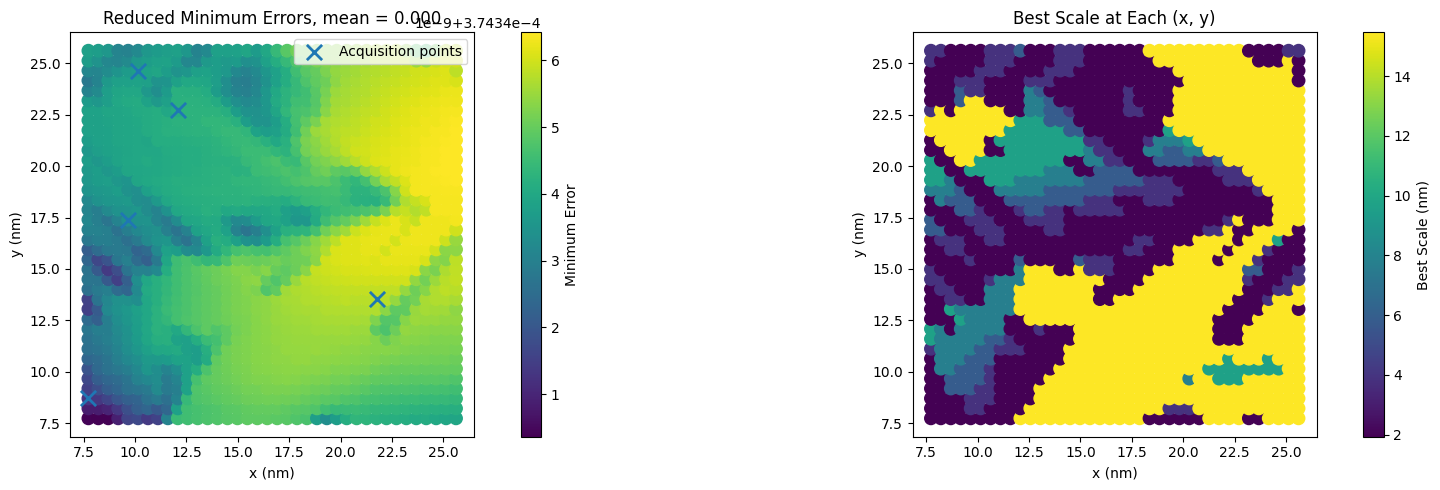

Train indices set size: 229, Test indices set size: 1215

Active Learning Iteration 18/20
Augmented images shape: (1374, 32, 32), Augmented spectra shape: (1374, 192), Augmented coordinates shape: (1374, 3)
Augmented images shape: (7290, 32, 32), Augmented spectra shape: (7290, 192), Augmented coordinates shape: (7290, 3)
Current augmented train data: 1374, Current augmented test data: 7290


 91%|█████████ | 91/100 [00:30<00:02,  3.01it/s, train_loss=0.0000, val_loss=0.0000]

SWA triggered at epoch 90


 92%|█████████▏| 92/100 [00:12<00:01,  7.15it/s, train_loss=0.0380, val_loss=0.0507]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:14<00:00,  7.13it/s, train_loss=0.0404, val_loss=0.0470]


Augmented images shape: (8664, 32, 32), Augmented spectra shape: (8664, 192), Augmented coordinates shape: (8664, 3)


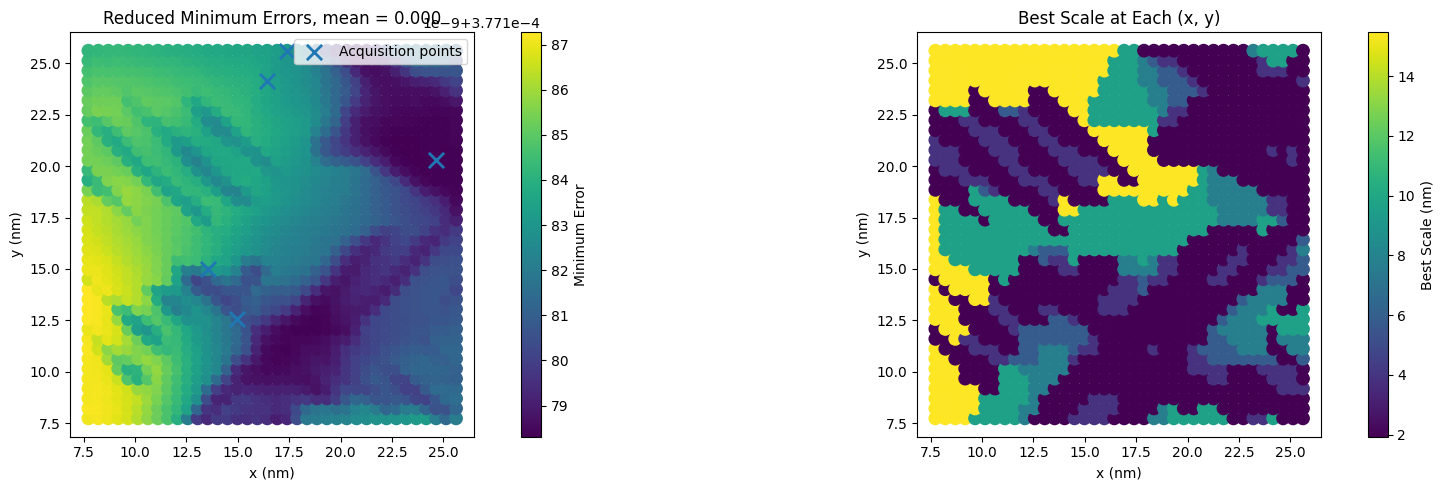

Train indices set size: 234, Test indices set size: 1210

Active Learning Iteration 19/20
Augmented images shape: (1404, 32, 32), Augmented spectra shape: (1404, 192), Augmented coordinates shape: (1404, 3)
Augmented images shape: (7260, 32, 32), Augmented spectra shape: (7260, 192), Augmented coordinates shape: (7260, 3)
Current augmented train data: 1404, Current augmented test data: 7260


 91%|█████████ | 91/100 [00:30<00:02,  3.11it/s, train_loss=0.0000, val_loss=0.0000]

SWA triggered at epoch 90


 92%|█████████▏| 92/100 [00:13<00:01,  7.20it/s, train_loss=0.0389, val_loss=0.0386]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:14<00:00,  7.00it/s, train_loss=0.0418, val_loss=0.0423]


Augmented images shape: (8664, 32, 32), Augmented spectra shape: (8664, 192), Augmented coordinates shape: (8664, 3)


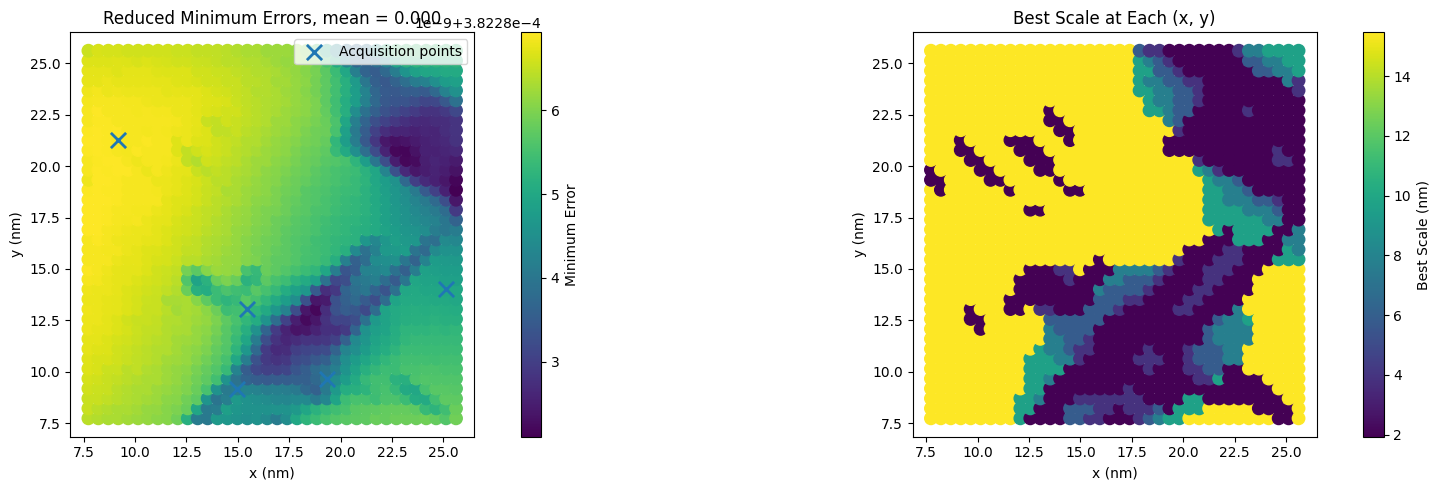

Train indices set size: 239, Test indices set size: 1205

Active Learning Iteration 20/20
Augmented images shape: (1434, 32, 32), Augmented spectra shape: (1434, 192), Augmented coordinates shape: (1434, 3)
Augmented images shape: (7230, 32, 32), Augmented spectra shape: (7230, 192), Augmented coordinates shape: (7230, 3)
Current augmented train data: 1434, Current augmented test data: 7230


 91%|█████████ | 91/100 [00:29<00:02,  3.10it/s, train_loss=0.0000, val_loss=0.0000]

SWA triggered at epoch 90


 92%|█████████▏| 92/100 [00:12<00:01,  7.11it/s, train_loss=0.0480, val_loss=0.0450]

SWA triggered at epoch 90


100%|██████████| 100/100 [00:14<00:00,  7.09it/s, train_loss=0.0367, val_loss=0.0475]


Augmented images shape: (8664, 32, 32), Augmented spectra shape: (8664, 192), Augmented coordinates shape: (8664, 3)


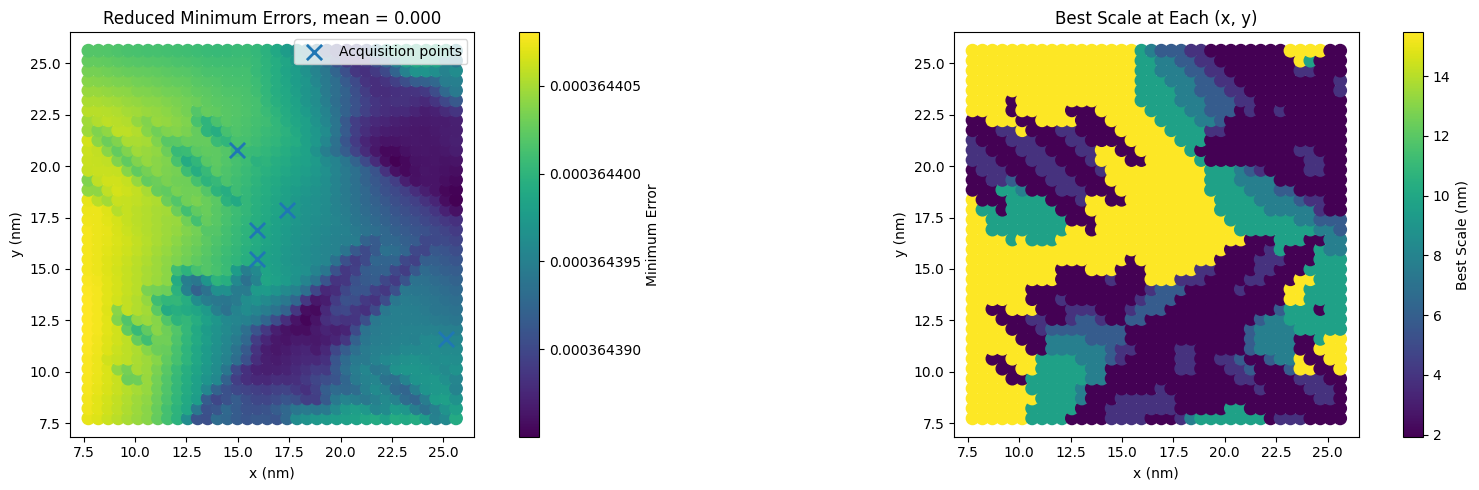

Train indices set size: 244, Test indices set size: 1200


In [ ]:
# original indices for the full dataset
original_indices = np.arange(len(images_all))
indices_train, indices_test = train_test_split(original_indices, train_size=0.1, random_state=42)

output_dict = {
    "reduced_errors": [],
    "reduced_errors_im2spec": [],
    "reduced_scales": [],
    "reduced_coords": [],
    "train_indices": [],
    "test_indices": [],
    "im2spec_test_mismatches": [],
    "pred_error_test": [],
    "predicted_errors_all": []
}



print("len(images):", len(images))
print("len(indices_train):", len(indices_train))
print("len(indices_test):", len(indices_test))


for i in range(acquisition_iterations):
    print(f"\nActive Learning Iteration {i+1}/{acquisition_iterations}")

    
    current_images_train, current_spectra_train, coordinates_train = augment_images_by_indices(indices_train, images_all, spectra_all, swap_coordinates_all, WS_init, WS, d_WS, append_image_type=append_image_type)
    images_test_aug, spectra_test_aug, coordinates_test = augment_images_by_indices(indices_test, images_all, spectra_all, swap_coordinates_all, WS_init, WS, d_WS, append_image_type=append_image_type)

    print(f"Current augmented train data: {current_images_train.shape[0]}, Current augmented test data: {images_test_aug.shape[0]}")


    # ---------------- Datasets ----------------

    # recreate datasets
    im2spec_al_training_dataset = TensorDataset(
        torch.tensor(current_images_train, dtype=torch.float32),
        torch.tensor(current_spectra_train, dtype=torch.float32),
    )

    # validation dataset
    im2spec_al_val_dataset = TensorDataset(
        torch.tensor(images_test_aug, dtype=torch.float32),
        torch.tensor(spectra_test_aug, dtype=torch.float32),
    )


    # ------------------- IM2spec model training -------------------

    imspec_model = get_model(model_type, in_dim, out_dim, latent_dim=latent_dim, device=device)

    imspec_model, al_im2spec_train_loss, al_im2spec_val_loss = train_model(
        imspec_model,
        im2spec_al_training_dataset,
        n_batches=6,
        lr=1e-3,
        patience= 10,
        n_epochs=n_epochs_im2spec, #reduced epochs for faster retraining
        partial_train=False,
        val_dataset=im2spec_al_val_dataset,
        use_swa=use_swa,
        last_swa_epochs = last_swa_epochs
    )


    # ------------------------- Error model training -------------------------

    # estimate errors again with the appended dataset
    error_mean_al, _, _ = err_estimation(imspec_model, current_images_train, current_spectra_train, error_type=error_type)
    error_norm = Norm_0to1(data=error_mean_al)
    error_mean_al = error_norm.normalize(error_mean_al)
    error_targets_al = error_mean_al.astype(np.float32).reshape(-1, 1)

    # retrain and reinitialize error model
    with torch.no_grad():
        latent_dim = imspec_model.encoder(torch.tensor(images[:1], dtype=torch.float32, device=device).unsqueeze(1)).shape[1]
    error_model = CustomDecoder(encoder=imspec_model.encoder, embed_dim=latent_dim, target_size=1).to(device)

    error_al_training_dataset = TensorDataset(
        torch.tensor(current_images_train, dtype=torch.float32),
        torch.tensor(error_targets_al, dtype=torch.float32),
    )


    error_model, al_error_train_loss, al_error_val_loss = train_model(
        error_model,
        error_al_training_dataset,
        n_batches=6,
        lr=1e-3,
        patience=10,
        n_epochs=n_epochs_error,
        partial_train=True,
        val_dataset=  None, # error_al_val_dataset,
        use_swa=use_swa,
        last_swa_epochs = last_swa_epochs
    )



    # ------------- Test set evaluation for error model and im2spec model --------------

    # test set errors to evaluate error model. This is only for benchmarking and cannot be used for acquisition since it requires knowledge of the true errors, which we don't have in practice.
    error_mean_test_al, _, _ = err_estimation(imspec_model, images_test_aug, spectra_test_aug, error_type=error_type)
    error_targets_test_al = error_mean_test_al.astype(np.float32).reshape(-1, 1)
    output_dict["im2spec_test_mismatches"].append(error_mean_test_al.flatten())

    # Re-predict errors on the entire dataset with the newly trained error_model
    predicted_errors_test = predict_spectra(error_model, images_test_aug, ensemble=False)
    predicted_errors_test = error_norm.denormalize(predicted_errors_test)
    predicted_errors_test = np.clip(predicted_errors_test, 0, None) # Clip negative errors
    output_dict["pred_error_test"].append(predicted_errors_test.flatten())



    # ---------------------- Compute errors for the entire augmented dataset ----------------------

    images_all_aug, spectra_all_aug, scale_coordinates = augment_images_by_indices(original_indices, images_all, spectra_all, swap_coordinates_all, WS_init, WS, d_WS, append_image_type=append_image_type)

    error_im2spec_al, _, _ = err_estimation(imspec_model, images_all_aug, spectra_all_aug, error_type=error_type)
    error_im2spec_al = error_im2spec_al.flatten()




    # Re-predict errors on the entire dataset with the newly trained error_model
    predicted_errors_current_iter = predict_spectra(error_model, images_all_aug, ensemble=False)
    predicted_errors_current_iter = error_norm.denormalize(predicted_errors_current_iter)
    predicted_errors_current_iter = np.clip(predicted_errors_current_iter, 0, None) # Clip negative errors


    #  ---------------------------------- Reduced errors and scales ----------------------------------
    reduced_errors, reduced_coords = reduce_errors_and_coords(predicted_errors_current_iter, scale_coordinates)
    reduced_errors_im2spec = error_im2spec_al[find_row_indices(scale_coordinates, reduced_coords)]  # useful only for benchmarking. cannot use for acquisition since it requires knowledge of the true errors, which we don't have in practice.
    

    reduced_errors_test = reduced_errors[indices_test]
    output_dict["reduced_errors"].append(reduced_errors)
    output_dict["reduced_coords"].append(reduced_coords)
    output_dict["reduced_errors_im2spec"].append(reduced_errors_im2spec)
    output_dict["reduced_scales"].append(reduced_coords[:, 2])
    output_dict["train_indices"].append(indices_train.copy())
    output_dict["test_indices"].append(indices_test.copy())
    output_dict["predicted_errors_all"].append(predicted_errors_current_iter.flatten())



# ---------------------- Acquisition of new points based on the acquisition method ----------------------

    if acquisition_method == "distance":

        aq_ind, aq_vals = distance_acq_fn(
            reduced_errors, # Pass full errors
            beta=1,
            lambda_=1,
            sample_next_points=num_new_points,
            exclude_indices=indices_train.reshape(-1) # Exclude based on positional indices
        )

    elif acquisition_method == "random":

        aq_ind = np.random.choice(
            indices_test,
            size=num_new_points,
            replace=False
        )
    else:
        raise ValueError(f"Unknown acquisition method: {acquisition_method}")

    plot_reduced_errors_and_scales(reduced_errors, reduced_coords, aq_indices = aq_ind)


    # update train/test splits
    indices_train = np.concatenate([indices_train, aq_ind]).ravel()

    indices_test = indices_test[~np.isin(indices_test, aq_ind)]

    print(f"Train indices set size: {len(indices_train)}, Test indices set size: {len(indices_test)}")



In [ ]:
import os
from google.colab import drive
folder = "/content/drive/MyDrive/active_learning_results_1.8"
os.makedirs(folder, exist_ok=True)
filename = f"al_{model_type}_{error_type}_WS{WS}_latent{latent_dim}_append{append_image_type}_{acquisition_iterations}iters_{num_new_points}pts_{acquisition_method}acq.h5"
output_file = os.path.join(folder, filename)
print("About to save...")
print("Before saving:")
print("reduced_coords length:", len(output_dict["reduced_coords"]))
print("reduced_errors length:", len(output_dict["reduced_errors"]))
save_h5_ragged(output_file, output_dict)
print("Finished saving.")

About to save...
Before saving:
reduced_coords length: 20
reduced_errors length: 20
Finished saving.


In [ ]:
import os

print(os.listdir(folder))

['al_FNO_L1_WS24_latent5_appendinterpolate_20iters_5pts_randomacq.h5', 'al_FNO_attn_L1_WS24_latent5_appendinterpolate_20iters_5pts_randomacq.h5', 'al_FNO_attn_L1_WS24_latent5_appendinterpolate_20iters_5pts_distanceacq.h5', 'al_FNO_L1_WS24_latent5_appendinterpolate_20iters_5pts_distanceacq.h5', 'al_im2spec_L1_WS24_latent5_appendpad_20iters_5pts_randomacq.h5', 'al_im2spec_attn_L1_WS24_latent5_appendpad_20iters_5pts_distanceacq.h5', 'al_im2spec_L1_WS24_latent5_appendpad_20iters_5pts_distanceacq.h5', 'al_im2spec_attn_L1_WS24_latent5_appendpad_20iters_5pts_randomacq.h5']


In [ ]:
print(os.path.exists(output_file))
print(os.path.getsize(output_file) if os.path.exists(output_file) else "missing")

True
4289472


In [ ]:
import h5py

with h5py.File(output_file, "r") as f:
    print(list(f.keys()))
    print("reduced_coords contents:", list(f["reduced_coords"].keys())[:10])
    print("Number of datasets:", len(f["reduced_coords"]))

['im2spec_test_mismatches', 'pred_error_test', 'predicted_errors_all', 'reduced_coords', 'reduced_errors', 'reduced_errors_im2spec', 'reduced_scales', 'test_indices', 'train_indices']
reduced_coords contents: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17']
Number of datasets: 20


In [ ]:
print(output_file)

/content/drive/MyDrive/active_learning_results1/al_FNO_attn_L1_WS24_latent5_appendpad_20iters_5pts_distanceacq.h5


In [ ]:
print(output_dict.keys())

dict_keys(['reduced_errors', 'reduced_errors_im2spec', 'reduced_scales', 'reduced_coords', 'train_indices', 'test_indices', 'im2spec_test_mismatches', 'pred_error_test', 'predicted_errors_all'])


In [ ]:
print(os.getcwd())
print(output_file)
print(os.path.isdir(folder))
print(os.path.isfile(output_file))

/content/NN_Error
/content/drive/MyDrive/active_learning_results1/al_FNO_attn_L1_WS24_latent5_appendpad_20iters_5pts_distanceacq.h5
True
True


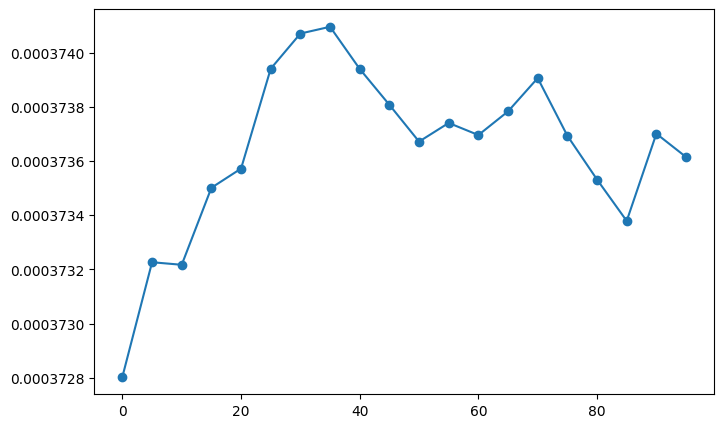

In [ ]:
train_indices_arr = output_dict["train_indices"]
test_indices_arr = output_dict["test_indices"]
reduced_errors_arr = np.array(output_dict["reduced_errors_im2spec"])

test_reduced_errors = [reduced_errors_arr[i][test_indices_arr[i]] for i in range(acquisition_iterations)]

mean_test_reduced_errors = [np.mean(test_reduced_errors[i]) for i in range(acquisition_iterations)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(acquisition_iterations)*num_new_points, mean_test_reduced_errors, marker='o')
plt.show()


In [ ]:
# Initial training indices (saved before the AL loop)
initial_train_indices = output_dict["train_indices"][0]

# Final training indices
final_train_indices = output_dict["train_indices"][-1]

# Only points acquired during active learning
acquired_indices = np.setdiff1d(final_train_indices, initial_train_indices)

# Coordinates of acquired points
acquired_coords = reduced_coords[acquired_indices]

plt.figure(figsize=(7, 7))
plt.imshow(topo, cmap="gray", origin="lower")

plt.scatter(
    acquired_coords[:, 1],   # x-coordinate for plotting
    acquired_coords[:, 0],   # y-coordinate for plotting
    c="red",
    s=40,
    edgecolors="white",
    linewidths=0.8,
    label="Acquired points"
)

plt.legend()
plt.title("Active Learning Acquired Points")
plt.axis("off")
plt.show()